#**BANK CUSTOMER SEGMENTATION (1M+ Transactions)**
By Praveen Kumar

IIT BHU CIV'27

###**Table Of Contents**

  1.Business Understanding

  2.Data Understanding

  3.Data Preparation

  4.Exploratory Data Analysis

  5.RFM Analysis

     5.1 Feature Engineering
     5.2 Power Transforms

  6.Modeling

  7.Cluster Analysis
  
     7.1 Selecting no. of Clusters
     7.2 RFM based validation for chosen K
     7.3 Final Customer Segmentation Profiling
     7.4 t-SNE Visualization

  8.Business Recommendation

  9.Discussion

  10.Conclusion

#**1.BUSINESS UNDERSTANDING**
Most banks have a large customer base - with different characteristics in terms of age, income, values, lifestyle, and more. Customer segmentation is the process of dividing a customer dataset into specific groups based on shared traits.

##**1.1 Project Overview**
The banking institution serves a diverse customer base but currently markets its products without clearly defined customer segments. By analysing customer data, meaningful patterns in behaviour and financial activity can be identified, enabling customers with similar characteristics to be grouped together.

Customer segmentation helps the bank deliver personalised products and targeted marketing campaigns, improving customer engagement while optimising marketing costs. In this project, K-Means Clustering, an unsupervised machine learning technique, will be used to segment customers into distinct groups, allowing the bank to better understand each segment and develop more effective business strategies.

Here's a high-level overview of the workflow followed in this project:

* Define the problem in-hands and measurement criterias.

* Explore, understand, and clean the provided datasets.

* Prepare final dataset grouped by customers.

* Transform final dataset appropriately before fitting model.

* Fit model on final dataset and predict cluster labels.

* Explore distributions among formed clusters.

* Discuss outcomes and make recommendations.

##**1.2 Problem Statement**

Banks generate large volumes of customer transaction data, but extracting meaningful insights from this data remains a challenge. Understanding customer behaviour, spending patterns, and transaction habits is essential for designing personalised banking services and improving customer experience.

The objectives of this project are to:

* Perform customer segmentation using K-Means Clustering to identify distinct customer groups.

* Analyse transaction patterns to uncover customer spending and banking behaviour.
* Conduct Recency, Frequency, and Monetary (RFM) analysis to evaluate customer value and engagement.
* Explore location-wise trends to identify regional variations in customer behaviour.
* Generate actionable insights to support personalised marketing, product recommendations, customer retention, and overall business decision-making.




## **1.3 Measurement Criteria**

To evaluate the effectiveness of the customer segmentation model, two categories of metrics will be considered:

- **Business Metrics** – Used to assess the business value and practical usefulness of the generated customer segments.
- **Technical Metrics** – Used to evaluate the quality and performance of the clustering algorithm.

---

### **1.3.1 Business Metrics**

The primary business objective is to understand customer behavior and create meaningful customer segments that can support data-driven decision making. The following business metrics will be considered:

1. **Recency, Frequency, and Monetary (RFM) Analysis**

   RFM analysis is used to evaluate customer value by considering:

   - **Recency (R):** How recently a customer made a transaction.
   - **Frequency (F):** How often a customer makes transactions.
   - **Monetary (M):** How much money a customer spends.

   Each customer is assigned an RFM score based on these three measures. The overall RFM score is calculated as:

   $$
   \text{RFM Score}=
   \frac{\text{Recency Score}+\text{Frequency Score}+\text{Monetary Score}}{3}
   $$

2. **Customer Segment Identification**

   The identified customer segments will be analyzed based on their demographic and transactional characteristics. These insights can help the bank design personalized marketing campaigns, recommend suitable financial products, improve customer retention, and optimize business strategies.

---

### **1.3.2 Technical Metrics**

To evaluate the performance of the K-Means clustering algorithm and determine the optimal number of clusters, two technical metrics will be used:

#### **1. Silhouette Coefficient**

The Silhouette Coefficient measures how well each data point fits within its assigned cluster compared to neighboring clusters.

Its value ranges between **-1 and 1**:

- **+1:** The sample is well matched to its own cluster and far from neighboring clusters.
- **0:** The sample lies near the boundary between two clusters.
- **-1:** The sample is likely assigned to the wrong cluster.

The silhouette value for a data point is defined as:

$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}
$$

where:

- $a(i)$ is the average distance between point $i$ and all other points in the same cluster.
- $b(i)$ is the average distance between point $i$ and points in its nearest neighboring cluster.

The overall Silhouette Score is the average of all individual silhouette values:

$$
SC=\frac{1}{n}\sum_{i=1}^{n}s(i)
$$

A higher Silhouette Score indicates better-defined and more compact clusters.

---

#### **2. Sum of Squared Errors (SSE)**

The Sum of Squared Errors (SSE), also known as **Within-Cluster Sum of Squares (WCSS)**, measures the compactness of clusters by calculating the squared distance between each data point and its corresponding cluster centroid.

It is defined as:

$$
SSE=\sum_{i=1}^{k}\sum_{x\in C_i}\|x-\mu_i\|^2
$$

where:

- $k$ = Number of clusters
- $C_i$ = Set of points belonging to cluster $i$
- $\mu_i$ = Centroid of cluster $i$

As the number of clusters increases, the SSE generally decreases because data points become closer to their assigned centroids.

To determine the optimal number of clusters, the **Elbow Method** is used by plotting SSE against different values of **k**. The optimal value of **k** is selected at the point where adding more clusters results in only a marginal decrease in SSE.

#**2. DATA UNDERSTANDING**

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro,
    normaltest,
    skew,
    kurtosis,
    ttest_ind,
    chi2_contingency,
    f_oneway,
    pearsonr
)
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.spatial.distance import cdist
from sklearn.ensemble import IsolationForest



In [ ]:
data=pd.read_csv('/content/bank_transactions.csv')
data.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [ ]:
data.shape

(1048567, 9)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [ ]:
data.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
for x in ['CustGender','CustLocation']:
  print(x)
  print(data[x].value_counts())

CustGender
CustGender
M    765530
F    281936
T         1
Name: count, dtype: int64
CustLocation
CustLocation
MUMBAI                           103595
NEW DELHI                         84928
BANGALORE                         81555
GURGAON                           73818
DELHI                             71019
                                  ...  
SAHIBGANJ                             1
24 PARGANAS SOUTH 24 PARGANAS         1
PREMISES KALYANI NAGAR PUNE           1
ARRAH                                 1
AREA WHITE FIELD BANGALORE            1
Name: count, Length: 9355, dtype: int64


In [ ]:
data['CustLocation'].nunique()

9355

In [ ]:
counts = data["CustLocation"].value_counts()
for upper in range(100000, 0, -5000):
    lower = upper - 5000

    if upper == 100000:
        n = (counts >= upper).sum()
        print(f">= {upper}: {n}")
    else:
        n = ((counts >= lower) & (counts < upper)).sum()
        print(f"{lower} - {upper}: {n}")

>= 100000: 1
90000 - 95000: 0
85000 - 90000: 0
80000 - 85000: 2
75000 - 80000: 0
70000 - 75000: 2
65000 - 70000: 0
60000 - 65000: 0
55000 - 60000: 0
50000 - 55000: 0
45000 - 50000: 0
40000 - 45000: 0
35000 - 40000: 0
30000 - 35000: 2
25000 - 30000: 1
20000 - 25000: 2
15000 - 20000: 2
10000 - 15000: 3
5000 - 10000: 5
0 - 5000: 9335


In [ ]:
print((data['CustGender']=="M").sum()*100/(data.shape[0]))
print((data['CustGender']=="F").sum()*100/(data.shape[0]))

73.00725657015718
26.88774298638046


`CustLocation` **is extremely skewed.**

We have a small number of locations containing a huge proportion of customers and thousands of locations containing only a handful.

For segmentation, this suggests that city-level location may not be a very useful KMeans feature unless we clean it substantially.

### Interpretation of Customer Location Distribution

* The `CustLocation` variable contains **9,355 unique locations**, indicating a high geographical diversity among customers.
* The distribution is **highly skewed**, with a small number of locations having a very large number of customers.
* **Mumbai** is the most frequent location, with more than **100,000 customers**.
* Only **20 locations** have a frequency of **5,000 or more customers**.
* In contrast, **9,335 locations** have fewer than **5,000 customers**, indicating a strong **long-tail distribution**.
* Many locations have very few customers, suggesting that the location data contains numerous **rare categories**.
* Some entries appear to represent **areas or addresses rather than standardized city names**, indicating potential inconsistency in the location data.
* Due to the large number of unique values and its categorical nature, directly using `CustLocation` in **K-Means clustering** may lead to a high-dimensional and sparse feature space.


#**3. DATA PREPARATION**

Some data is missing, as compared to 1M+ rows we could drop the null values as their count is very less but doing so will lead to losing a lot of customers information , so rather than that we will go with imputation.

1.`CustomerDOB`--3397 --> For such segmentation task we know rather than DOB customers age is more relevant so we can impute the missing DOB with the median age.

2.`CustGender`--1100 --> We can impute it as Unknown/U

3.`CustLocation`--151 --> We can impute it as Unknown/U

4.`CustAccountBalance`--2369 -->

  (I)Only 2,369 values are missing, which represents a very small proportion of the dataset. Since account balance is an important feature for customer segmentation, imputing these values could introduce assumptions and distort the actual financial characteristics of customers. Therefore, these records are excluded from the clustering dataset rather than being imputed. However, the excluded records are stored separately for potential future analysis.

  **OR**

  (II)Based on the location we can find the median salaries for the people living int that area and can replace it with the median account balance only for those customers whose location is known

                                  Location known?
                                  /            \
                                Yes             No
                                ↓               ↓
                        Location median      Overall median
                                ↓               ↓
                        Impute balance       Impute balance


### **1. DOB and Age Handling**

* Converted `CustomerDOB` into date format.
* Corrected DOBs where years like `2057` were actually `1957`.
* Kept missing DOB values as `NaT`.
* Calculated `Age` using the reference date **08-08-2021**.
* Did not impute the `CustomerDOB` column.
* Imputed only the missing values in `Age` using the **median age**.
* Added an `Age_missing` column to identify customers whose DOB was missing.


In [ ]:
df1 = data.copy()

df1["CustomerDOB"] = pd.to_datetime(
    df1["CustomerDOB"],
    format="%d/%m/%y",
    errors="coerce"
)

reference_date = pd.Timestamp("2021-08-08")
mask = df1["CustomerDOB"] > reference_date

df1.loc[mask, "CustomerDOB"] = (
    df1.loc[mask, "CustomerDOB"] - pd.DateOffset(years=100)
)

df1["Age"] = (
    (reference_date - df1["CustomerDOB"]).dt.days / 365.25
).round()

df1["Age_missing"] = df1["Age"].isna().astype(int)

df1["Age"] = df1["Age"].fillna(df1["Age"].median()).astype(int)

In [ ]:
df1.sample(n=10)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Age_missing
735947,T735948,C2517989,1983-01-13,M,GURGAON,19748.11,2/9/16,133028,2000.0,39,0
532616,T532617,C8198618,1990-03-30,M,CHANDIGARH,1067.86,23/8/16,225424,1385.0,31,0
409436,T409437,C5937760,1983-06-03,F,BANGALORE,47355.22,18/8/16,180027,2700.0,38,0
545411,T545412,C1922862,1990-04-12,F,RANCHI,10201.62,23/8/16,222324,200.0,31,0
411638,T411639,C5211376,1977-03-31,M,NOIDA,7722.23,18/8/16,205433,208.0,44,0
476975,T476976,C5119336,1993-06-10,F,HOSHIARPUR,35380.45,21/8/16,190950,1000.0,28,0
595987,T595988,C6623679,1982-02-01,M,HYDERABAD,99684.14,25/8/16,20146,1000.0,40,0
11642,T11643,C1394071,1995-02-09,M,NEW DELHI,4907.52,25/9/16,222758,2400.0,26,0
124679,T124680,C5737213,1988-05-27,M,MUMBAI,286.32,6/8/16,165000,135.0,33,0
558154,T558155,C1811718,1961-02-06,M,CHENNAI,9240.79,27/8/16,172944,3510.0,61,0


In [ ]:
df2=df1.copy()
df2["TransactionDate"] = pd.to_datetime(
    df1["TransactionDate"],
    format="%d/%m/%y",
    errors="coerce"
)
df2.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Age_missing
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,28,0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,64,0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,25,0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,48,0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,33,0


In [ ]:
df3=df2.copy()
df3["TransactionTime"] = pd.to_datetime(
    df1["TransactionTime"].astype(str).str.zfill(6),
    format="%H%M%S",
    errors="coerce"
).dt.time
df3.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Age_missing
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,28,0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,64,0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,25,0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,48,0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,33,0


In [ ]:
df4=df3.copy()
df4['CustGender']=df4["CustGender"].fillna("U")
df4['CustLocation']=df4["CustLocation"].fillna("U")
df5=df4.dropna(subset=['CustAccountBalance'])

In [ ]:
df5.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Age_missing
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,28,0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,64,0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,25,0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,48,0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,33,0


In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1046198 entries, 0 to 1048566
Data columns (total 11 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   TransactionID            1046198 non-null  object        
 1   CustomerID               1046198 non-null  object        
 2   CustomerDOB              985637 non-null   datetime64[ns]
 3   CustGender               1046198 non-null  object        
 4   CustLocation             1046198 non-null  object        
 5   CustAccountBalance       1046198 non-null  float64       
 6   TransactionDate          1046198 non-null  datetime64[ns]
 7   TransactionTime          1046198 non-null  object        
 8   TransactionAmount (INR)  1046198 non-null  float64       
 9   Age                      1046198 non-null  int64         
 10  Age_missing              1046198 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 

In [ ]:
dob_original = data["CustomerDOB"].copy()

dob_converted = pd.to_datetime(
    dob_original,
    format="%d/%m/%y",
    errors="coerce"
)

print("Original non-null:", dob_original.notna().sum())
print("Converted non-null:", dob_converted.notna().sum())
print("Converted to NaT:", dob_converted.isna().sum())

Original non-null: 1045170
Converted non-null: 987831
Converted to NaT: 60736


### Reason for Decrease in Non-Null `CustomerDOB`

* Initially, `CustomerDOB` had **1,045,170 non-null values**.
* After converting the column to datetime, only **985,637 values remained non-null**.
* Therefore, **59,533 values were converted to `NaT`**.
* This happened because `pd.to_datetime()` could not interpret some of the original values using the specified format `%d/%m/%y`.
* Since `errors="coerce"` was used, invalid or incorrectly formatted dates were automatically converted to **`NaT` (Not a Time)**.
* These values may contain **invalid dates, different date formats, or other malformed entries**.

Also `Age` column is more relevant to us now so we can let it be.


In [ ]:
customer_transaction_count = df5["CustomerID"].value_counts()

print("Customers with 1 transaction:",
      (customer_transaction_count == 1).sum())

print("Customers with >1 transaction:",
      (customer_transaction_count > 1).sum())

print("Maximum transactions by a customer:",
      customer_transaction_count.max())

Customers with 1 transaction: 739544
Customers with >1 transaction: 143056
Maximum transactions by a customer: 6


### **2.Customer Data Preparation**

* Identified customers who made **more than one transaction**.
* Separated these customers for further **RFM analysis**.
* For customers with multiple transactions, selected the transaction with the **maximum transaction amount**.
* Combined these maximum-value transactions with customers who made only one transaction.
* Created `df_one_time` containing **one row per customer**.
* Kept `df_repeat` separately with **all transactions of repeat customers** for RFM analysis.
* This allows us to perform general customer-level analysis using `df_one_time` while retaining complete transaction history for RFM analysis using `df_repeat`.


In [ ]:
transaction_count = df5["CustomerID"].value_counts()

repeat_ids = transaction_count[transaction_count > 1].index

df_single = df5[~df5["CustomerID"].isin(repeat_ids)].copy()

df_repeat_max = (
    df5[df5["CustomerID"].isin(repeat_ids)]
    .sort_values("TransactionAmount (INR)", ascending=False)
    .drop_duplicates("CustomerID")
    .copy()
)

df_one_time = pd.concat(
    [df_single, df_repeat_max],
    ignore_index=True
)

In [ ]:
print(df_one_time.shape[0])
print(df_one_time['TransactionID'].nunique())
print(df_one_time['CustomerID'].nunique())

882600
882600
882600


In [ ]:
df_repeat = df5[df5["CustomerID"].isin(repeat_ids)].copy()

In [ ]:
print(df_repeat.shape[0])
print(df_repeat['TransactionID'].nunique())
print(df_repeat['CustomerID'].nunique())

306654
306654
143056


In [ ]:
category_columns=['CustGender','CustLocation']
numeric_columns=['CustAccountBalance','TransactionAmount (INR)','Age']
date_time_columns=['CustomerDOB','TransactionDate','TransactionTime']

#**4.EXPLORATORY DATA ANALYSIS**

In [ ]:
df_eda=df_one_time.copy()

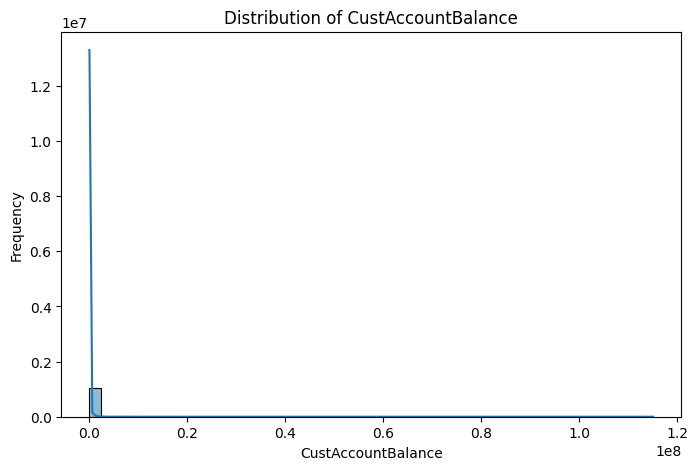

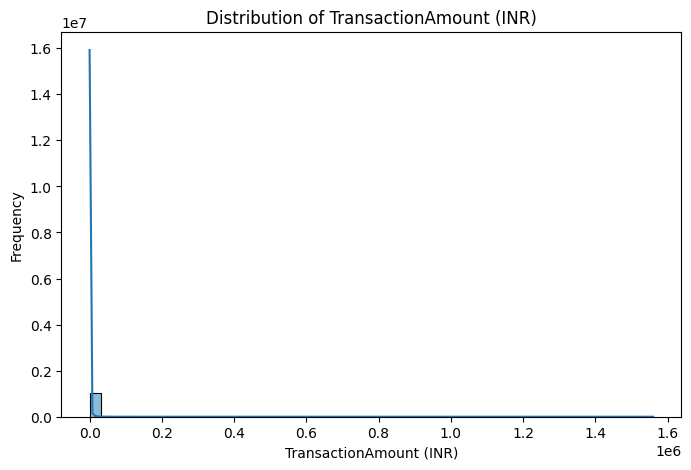

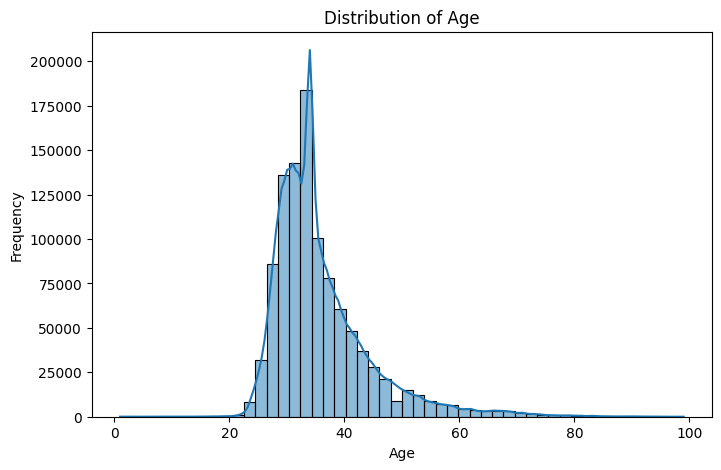

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df1, x=col, bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**1. Which gender contributes the most to transaction amount?**

In [ ]:
gender_transaction = (
    df_eda.groupby("CustGender")["TransactionAmount (INR)"]
       .sum()
       .sort_values(ascending=False)
)

gender_percentage = (
    gender_transaction / gender_transaction.sum() * 100
).round(2)

print(gender_percentage)

CustGender
M    71.56
F    28.30
U     0.14
T     0.00
Name: TransactionAmount (INR), dtype: float64


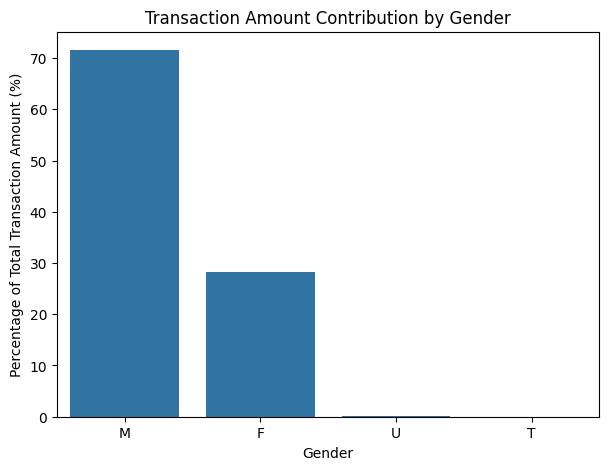

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    x=gender_percentage.index,
    y=gender_percentage.values
)

plt.title("Transaction Amount Contribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Total Transaction Amount (%)")
plt.show()

**2. Top 10 locations by transaction amount?**

In [ ]:
top_locations = (df_eda.groupby("CustLocation")["TransactionAmount (INR)"].sum().sort_values(ascending=False).head(10))
print(top_locations)

CustLocation
MUMBAI       1.718795e+08
NEW DELHI    1.543771e+08
BANGALORE    1.130043e+08
GURGAON      1.072172e+08
DELHI        1.011048e+08
KOLKATA      5.857950e+07
CHENNAI      4.249018e+07
NOIDA        4.225676e+07
PUNE         3.754650e+07
HYDERABAD    3.454494e+07
Name: TransactionAmount (INR), dtype: float64


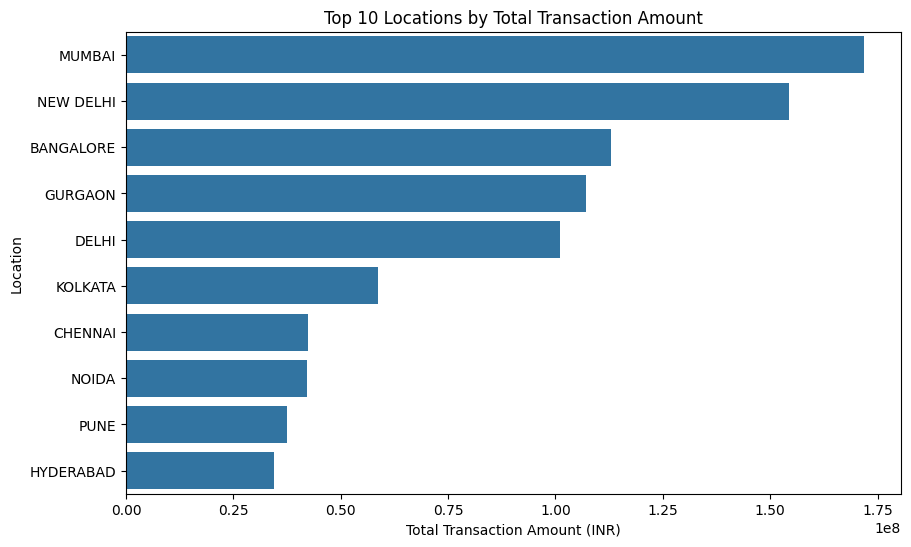

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values,y=top_locations.index)
plt.title("Top 10 Locations by Total Transaction Amount")
plt.xlabel("Total Transaction Amount (INR)")
plt.ylabel("Location")
plt.show()

**3. Which age group is doing the most transactions?**

In [ ]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18","18-25","26-35","36-45","46-55","56-65","65+"]
df_eda["AgeGroup"] = pd.cut(df_eda["Age"],bins=bins,labels=labels)
age_transaction = (df_eda.groupby("AgeGroup", observed=False)["TransactionAmount (INR)"].sum())
print(age_transaction)

AgeGroup
<18      9.773402e+05
18-25    1.743144e+07
26-35    7.593616e+08
36-45    4.671167e+08
46-55    2.033529e+08
56-65    7.807259e+07
65+      5.081345e+07
Name: TransactionAmount (INR), dtype: float64


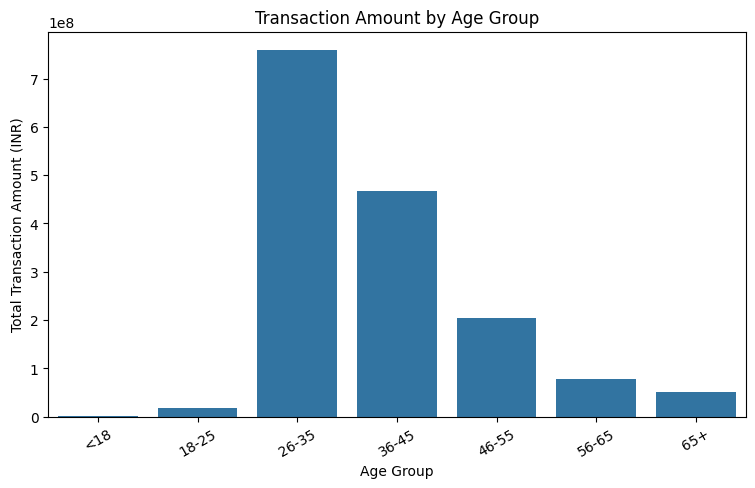

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(x=age_transaction.index,y=age_transaction.values)
plt.title("Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Transaction Amount (INR)")
plt.xticks(rotation=30)
plt.show()

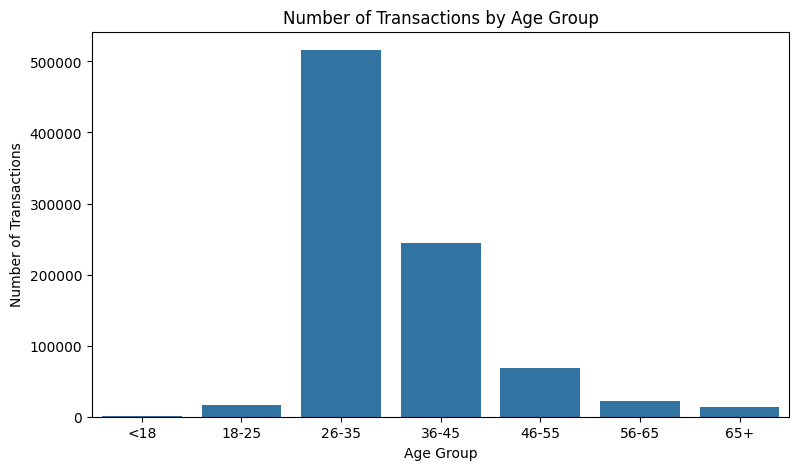

In [ ]:
age_count = (df_eda.groupby("AgeGroup", observed=False).size())
plt.figure(figsize=(9,5))
sns.barplot(x=age_count.index,y=age_count.values)
plt.title("Number of Transactions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.show()

**4. What are the peak transaction hours?**

First, we need to extract the date and time components into the required format so that they can be effectively used for analysis.

In [ ]:
df_eda=df5.copy()
df_eda["TransactionTime"] = pd.to_datetime(
    df_eda["TransactionTime"].astype(str).str.zfill(6),
    format="%H:%M:%S",
    errors="coerce"
)

In [ ]:
df_eda.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Age_missing
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,1900-01-01 14:32:07,25.0,28,0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,1900-01-01 14:18:58,27999.0,64,0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,1900-01-01 14:27:12,459.0,25,0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,1900-01-01 14:27:14,2060.0,48,0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,1900-01-01 18:11:56,1762.5,33,0


In [ ]:
df_eda["TransactionHour"] = df_eda["TransactionTime"].dt.hour
hourly_transactions = (
    df_eda["TransactionHour"].value_counts().sort_index())
print(hourly_transactions)

TransactionHour
0     17945
1      8832
2      5537
3      4699
4      4559
5      5345
6      8196
7     14541
8     23463
9     33027
10    42549
11    52280
12    60738
13    64850
14    66397
15    64691
16    64218
17    69077
18    79139
19    94192
20    96851
21    79963
22    53418
23    31691
Name: count, dtype: int64


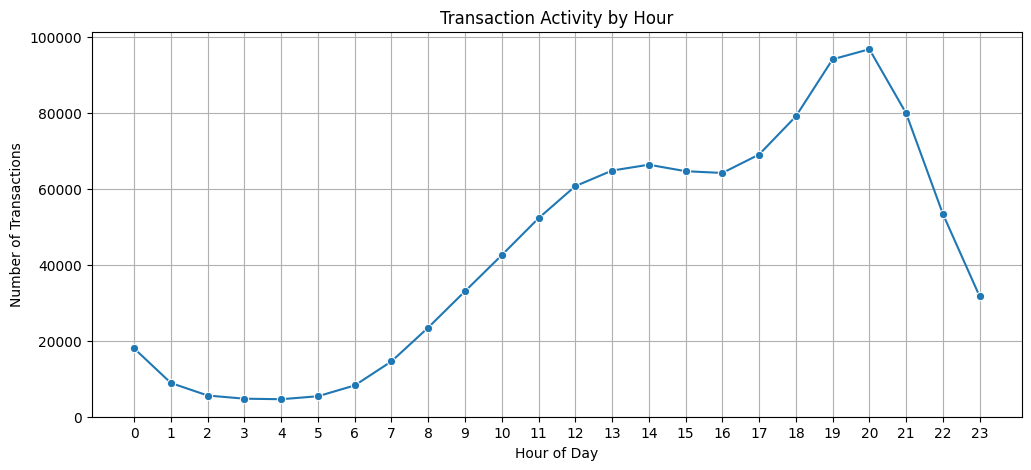

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(x=hourly_transactions.index,y=hourly_transactions.values,marker="o")
plt.title("Transaction Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(24))
plt.grid()
plt.show()

**5. Location-wise analysis**

In [ ]:
location_analysis = (
    df_eda.groupby("CustLocation")
       .agg(
           Total_Transaction_Amount=("TransactionAmount (INR)", "sum"),
           Transaction_Count=("TransactionAmount (INR)", "count"),
           Average_Transaction=("TransactionAmount (INR)", "mean"),
           Average_Balance=("CustAccountBalance", "mean")
       ).sort_values(
           "Total_Transaction_Amount",ascending=False
           )
       )
location_analysis.head(10)

,Total_Transaction_Amount,Transaction_Count,Average_Transaction,Average_Balance
CustLocation,,,,
MUMBAI,1.792728e+08,103325,1735.037615,153208.941042
NEW DELHI,1.604173e+08,84727,1893.343469,193443.289520
BANGALORE,1.183357e+08,81469,1452.524642,102736.753144
GURGAON,1.120185e+08,73746,1518.976826,177214.661584
DELHI,1.057675e+08,70817,1493.533000,108184.428499
KOLKATA,6.057846e+07,19950,3036.514389,165282.229328
CHENNAI,4.456630e+07,29935,1488.768925,91185.100823
NOIDA,4.437653e+07,32706,1356.831468,116919.369709
PUNE,3.925393e+07,25772,1523.123200,98984.646803


              Total_Transaction_Amount  Transaction_Count  \
CustLocation                                                
MUMBAI                    1.792728e+08             103325   
NEW DELHI                 1.604173e+08              84727   
BANGALORE                 1.183357e+08              81469   
GURGAON                   1.120185e+08              73746   
DELHI                     1.057675e+08              70817   
NOIDA                     4.437653e+07              32706   
CHENNAI                   4.456630e+07              29935   
PUNE                      3.925393e+07              25772   
HYDERABAD                 3.600238e+07              23008   
THANE                     2.709727e+07              21437   

              Average_Transaction  Average_Balance  
CustLocation                                        
MUMBAI                1735.037615    153208.941042  
NEW DELHI             1893.343469    193443.289520  
BANGALORE             1452.524642    102736.753144  
GU

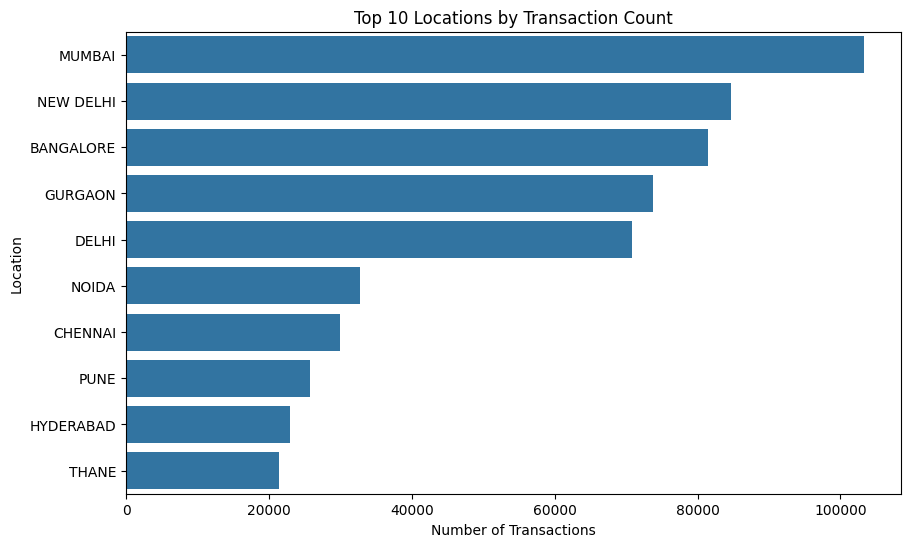

In [ ]:
top_location_count = (location_analysis.sort_values("Transaction_Count",ascending=False).head(10))
print(top_location_count)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_location_count["Transaction_Count"],
    y=top_location_count.index
)
plt.title("Top 10 Locations by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Location")
plt.show()

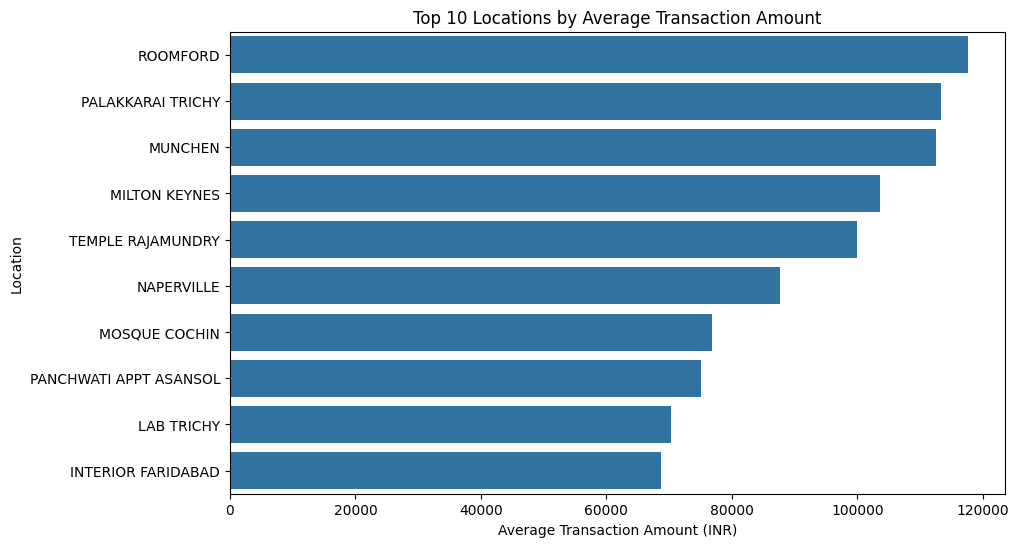

In [ ]:
top_avg_transaction = (
    location_analysis
    .sort_values("Average_Transaction", ascending=False)
    .head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_avg_transaction["Average_Transaction"],
    y=top_avg_transaction.index
)
plt.title("Top 10 Locations by Average Transaction Amount")
plt.xlabel("Average Transaction Amount (INR)")
plt.ylabel("Location")
plt.show()

##**Transaction-related analysis**
**A. Transaction amount distribution**

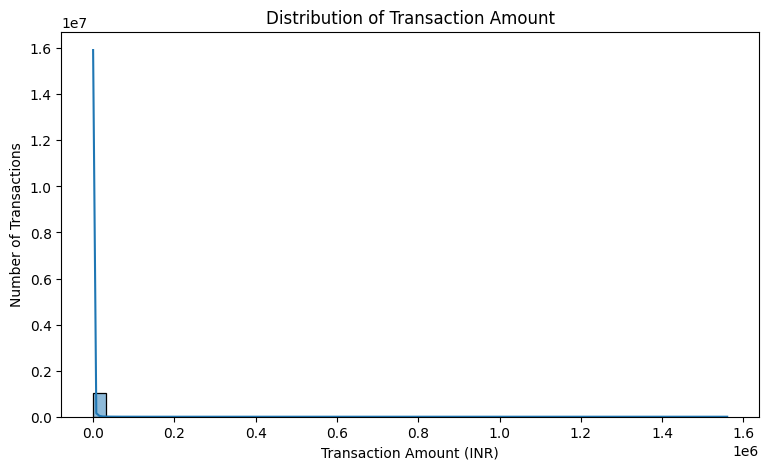

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(
    df1["TransactionAmount (INR)"],
    bins=50,
    kde=True
)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount (INR)")
plt.ylabel("Number of Transactions")
plt.show()

**B. Transaction amount by hour**

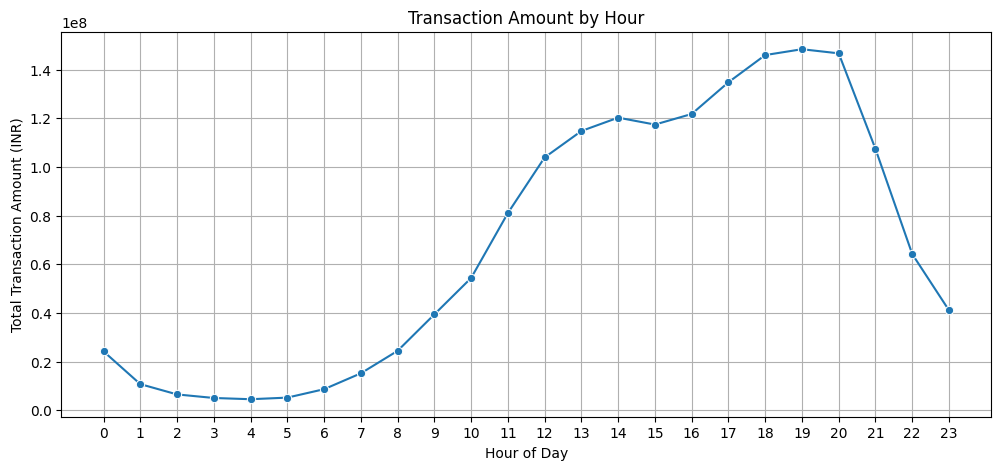

In [ ]:
hourly_amount = (
    df_eda.groupby("TransactionHour")["TransactionAmount (INR)"]
       .sum()
)
plt.figure(figsize=(12,5))
sns.lineplot(
    x=hourly_amount.index,
    y=hourly_amount.values,
    marker="o"
)
plt.title("Transaction Amount by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Transaction Amount (INR)")
plt.xticks(range(24))
plt.grid()
plt.show()

**C. Transaction amount by day of week**

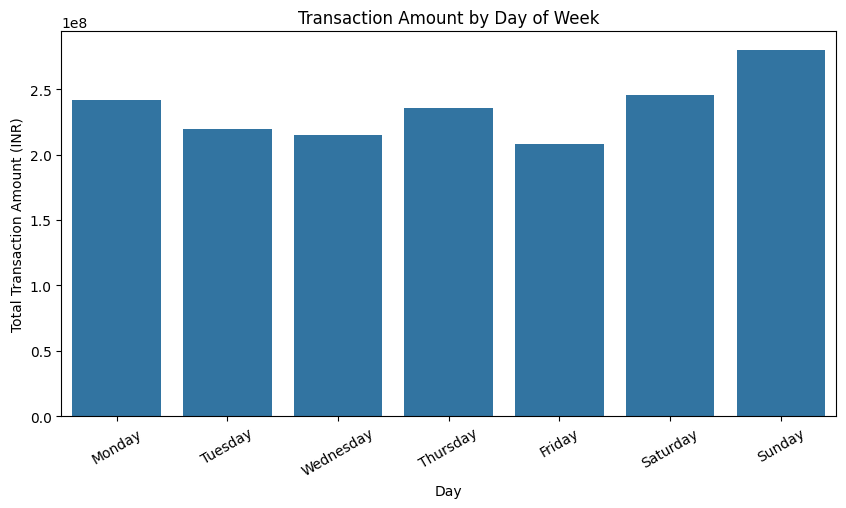

In [ ]:
df_eda["DayOfWeek"] = df_eda["TransactionDate"].dt.day_name()
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_transaction = (
    df_eda.groupby("DayOfWeek")["TransactionAmount (INR)"]
       .sum()
       .reindex(day_order)
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=day_transaction.index,
    y=day_transaction.values
)

plt.title("Transaction Amount by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Transaction Amount (INR)")
plt.xticks(rotation=30)
plt.show()

##**5.RFM ANALYSIS**

In [ ]:
df6=df_repeat.copy()
df6.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Age_missing
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,48,0
6,T7,C7126560,1992-01-26,F,MUMBAI,973.46,2016-08-02,17:38:06,566.0,30,0
10,T11,C5430833,1982-07-22,M,MOHALI,48429.49,2016-08-02,20:41:33,259.0,39,0
27,T28,C2416848,1993-04-01,M,CHENNAI,20986.66,2016-08-03,16:05:44,2235.0,28,0
41,T42,C7923455,1992-10-06,M,ANDHERI (EAST) MUMBAI,5810.82,2016-08-03,22:11:11,12.0,29,0


In [ ]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306654 entries, 3 to 1048566
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            306654 non-null  object        
 1   CustomerID               306654 non-null  object        
 2   CustomerDOB              288862 non-null  datetime64[ns]
 3   CustGender               306654 non-null  object        
 4   CustLocation             306654 non-null  object        
 5   CustAccountBalance       306654 non-null  float64       
 6   TransactionDate          306654 non-null  datetime64[ns]
 7   TransactionTime          306654 non-null  object        
 8   TransactionAmount (INR)  306654 non-null  float64       
 9   Age                      306654 non-null  int64         
 10  Age_missing              306654 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 28.1+ MB


In [ ]:
print(df6.shape[0])
print(df6['TransactionID'].nunique())
print(df6['CustomerID'].nunique())

306654
306654
143056


###**(I) Feature Engineering**

In [ ]:
# Reference date = one day after the last transaction in the dataset
reference_date = df6["TransactionDate"].max() + pd.Timedelta(days=1)
# Creating the customer-level RFM dataframe
rfm = df6.groupby("CustomerID").agg(
    Recency=(
        "TransactionDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "TransactionID",
        "count"
    ),
    Monetary=(
        "TransactionAmount (INR)",
        "sum"
    )
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,C1010011,26,2,5106.0
1,C1010014,76,2,1455.0
2,C1010031,79,2,1864.0
3,C1010035,56,2,750.0
4,C1010041,42,3,16917.0


In [ ]:
rfm.shape

(143056, 4)

In [ ]:
rfm["AvgTransactionAmount"] = (
    rfm["Monetary"] / rfm["Frequency"]
)

In [ ]:
customer_info = df_one_time[
    [
        "CustomerID",
        "CustGender",
        "CustLocation",
        "CustAccountBalance",
        "Age"
    ]
].copy()

rfm = rfm.merge(
    customer_info,
    on="CustomerID",
    how="left"
)

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgTransactionAmount,CustGender,CustLocation,CustAccountBalance,Age
0,C1010011,26,2,5106.0,2553.0,F,NOIDA,32500.73,29
1,C1010014,76,2,1455.0,727.5,F,MUMBAI,38377.14,29
2,C1010031,79,2,1864.0,932.0,M,TRICHY,8646.21,33
3,C1010035,56,2,750.0,375.0,M,NAVI MUMBAI,378013.09,41
4,C1010041,42,3,16917.0,5639.0,F,DELHI,34119.48,28


In [ ]:
rfm['CustLocation'].value_counts()

,count
CustLocation,
MUMBAI,15765
NEW DELHI,12629
BANGALORE,11112
GURGAON,10090
DELHI,9823
...,...
SHEOGANJ,1
AERODROME POST COIMBATORE,1
OPP IIITCAMPUS HYDERABAD,1


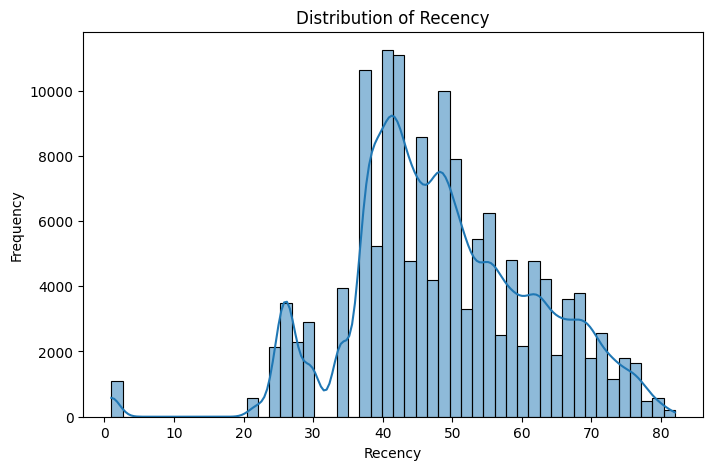

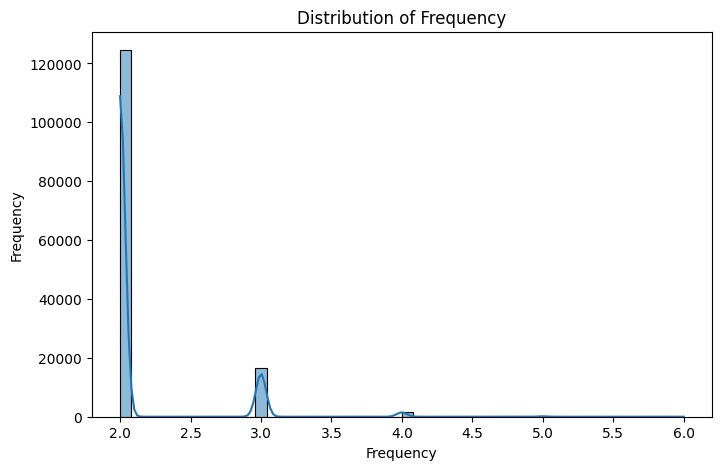

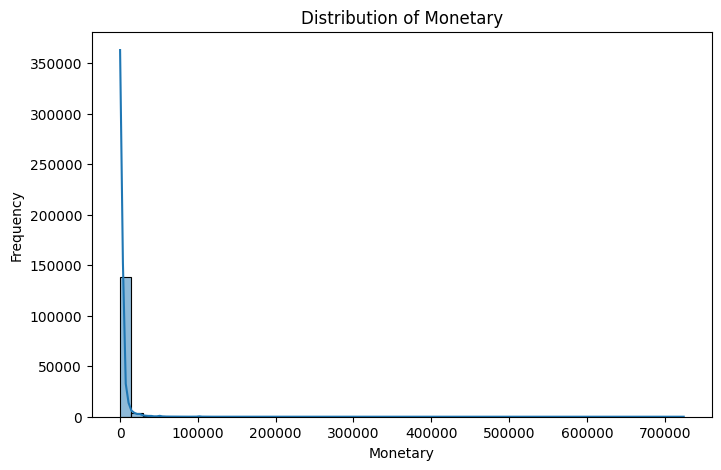

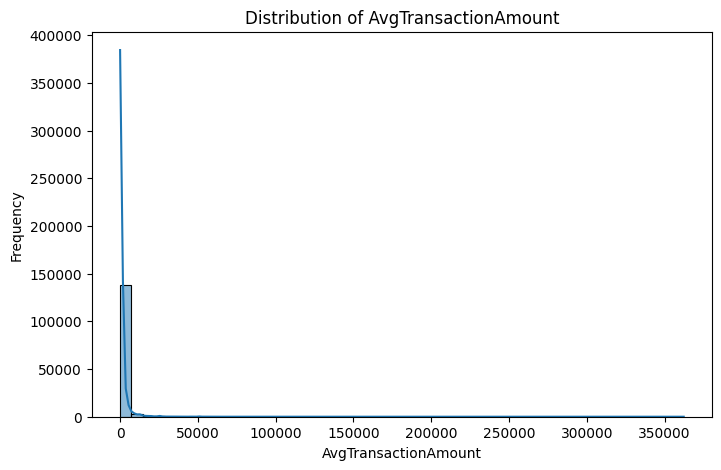

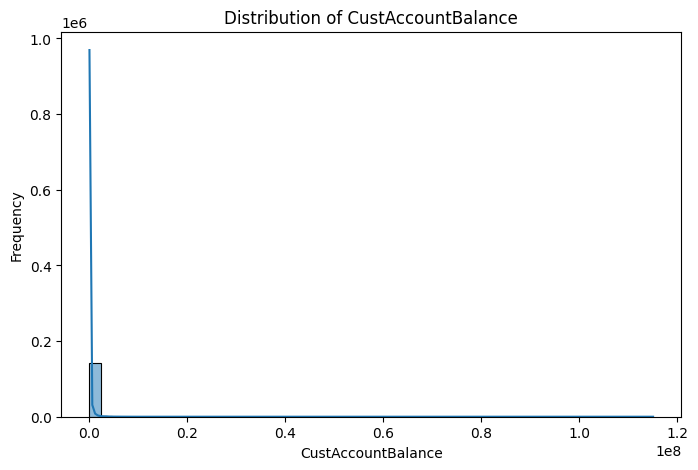

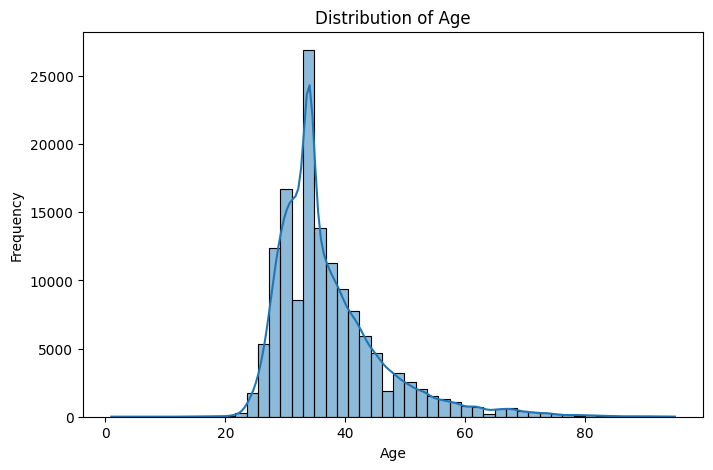

In [ ]:
numeric_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgTransactionAmount",
    "CustAccountBalance",
    "Age"
]

for col in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(rfm[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
distribution_summary = rfm[numeric_features].agg(
    ["min", "median", "mean", "max", "std", "skew"]
).T

distribution_summary

,min,median,mean,max,std,skew
Recency,1.0,47.00,48.596067,82.0,1.317611e+01,-0.049962
Frequency,2.0,2.00,2.143594,6.0,3.922307e-01,2.906749
Monetary,2.0,1423.00,3363.726937,724472.0,8.838803e+03,16.620553
AvgTransactionAmount,1.0,665.00,1568.803179,362236.0,4.118463e+03,16.269756
CustAccountBalance,0.0,23599.38,157028.366395,115035495.1,1.145287e+06,49.966155
Age,1.0,34.00,37.213644,95.0,8.995632e+00,1.733559


**The numerical features exhibit substantial right-skewness, particularly Monetary, Average Transaction Amount and Account Balance.**

 Since K-Means relies on distance calculations, extreme values can disproportionately influence cluster formation.Yeo-Johnson Power Transformation is therefore applied to reduce skewness and make the numerical features more suitable for distance-based clustering.

###**(II)Power Transforms**

## Why Power Transformation?

- The numerical features show significant right-skewness, especially:
  - `Monetary` → skewness ≈ 16.62
  - `AvgTransactionAmount` → skewness ≈ 16.27
  - `CustAccountBalance` → skewness ≈ 49.97
- K-Means uses Euclidean distance, so extreme values can disproportionately influence cluster formation.
- Power transformation reduces skewness and makes the numerical features more suitable for distance-based clustering.
- We use the **Yeo-Johnson transformation** because it can handle zero values, which are present in `CustAccountBalance`.
- We do not remove extreme values, because high balances and high transaction amounts may represent genuine high-value customers.

### Yeo-Johnson Transformation

For $x \geq 0$:

$$
T(x;\lambda)=
\begin{cases}
\dfrac{(x+1)^\lambda-1}{\lambda}, & \lambda \neq 0 \\[6pt]
\ln(x+1), & \lambda=0
\end{cases}
$$

For $x < 0$:

$$
T(x;\lambda)=
\begin{cases}
-\dfrac{(-x+1)^{2-\lambda}-1}{2-\lambda}, & \lambda \neq 2 \\[6pt]
-\ln(-x+1), & \lambda=2
\end{cases}
$$

where:

- $x$ = original feature value  
- $\lambda$ = transformation parameter estimated from the data  
- $T(x;\lambda)$ = transformed value  

### Why Yeo-Johnson instead of Log/Box-Cox?

- **Log transformation**: useful for right-skewed positive data, but requires additional handling for zero values.
- **Box-Cox**: requires strictly positive values.
- **Yeo-Johnson**: can handle zero and negative values, making it more flexible for our dataset.

**Therefore, Yeo-Johnson `PowerTransformer` is selected for preprocessing before K-Means clustering.**

In [ ]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgTransactionAmount",
    "CustAccountBalance",
    "Age"
]

In [ ]:
from sklearn.preprocessing import PowerTransformer
X = rfm[features].copy()
pt = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)
X_transformed = pt.fit_transform(X)

In [ ]:
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=features
)

X_transformed_df.head()

,Recency,Frequency,Monetary,AvgTransactionAmount,CustAccountBalance,Age
0,-1.696919,-1.167122e-14,1.035143,1.094951,0.129304,-1.060193
1,2.119378,-1.167122e-14,0.029508,0.080448,0.207421,-1.060193
2,2.356978,-1.167122e-14,0.231690,0.285188,-0.448395,-0.415926
3,0.556298,-1.167122e-14,-0.520545,-0.478403,1.426934,0.600117
4,-0.511891,7.845807e-14,1.951525,1.706242,0.152015,-1.240411


In [ ]:
print("Before Transformation:")
print(rfm[features].skew())

print("\nAfter Transformation:")
print(X_transformed_df.skew())

Before Transformation:
Recency                 -0.049962
Frequency                2.906749
Monetary                16.620553
AvgTransactionAmount    16.269756
CustAccountBalance      49.966155
Age                      1.733559
dtype: float64

After Transformation:
Recency                 0.052533
Frequency               0.000000
Monetary               -0.007803
AvgTransactionAmount   -0.009765
CustAccountBalance      0.056042
Age                    -0.369475
dtype: float64


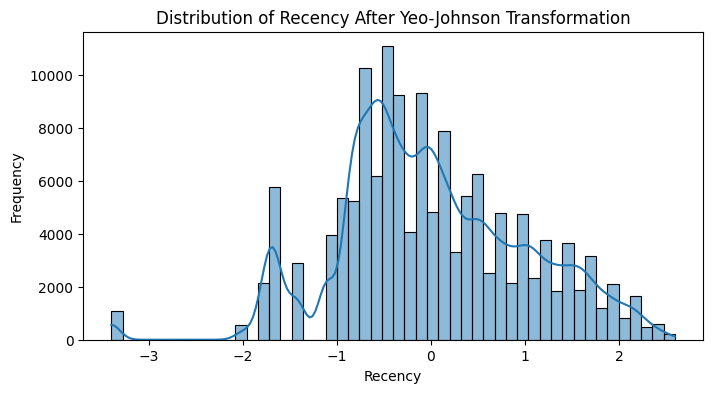

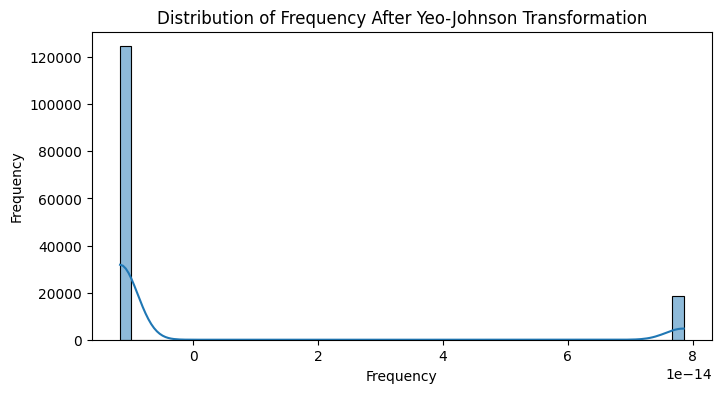

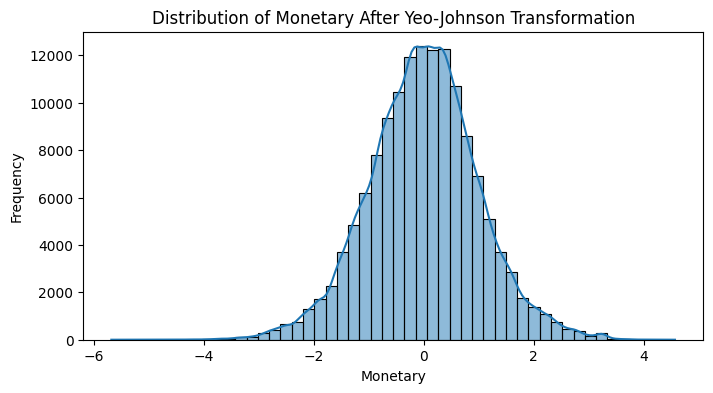

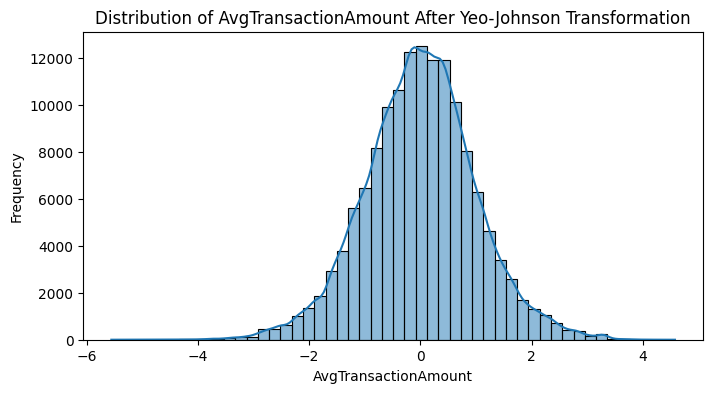

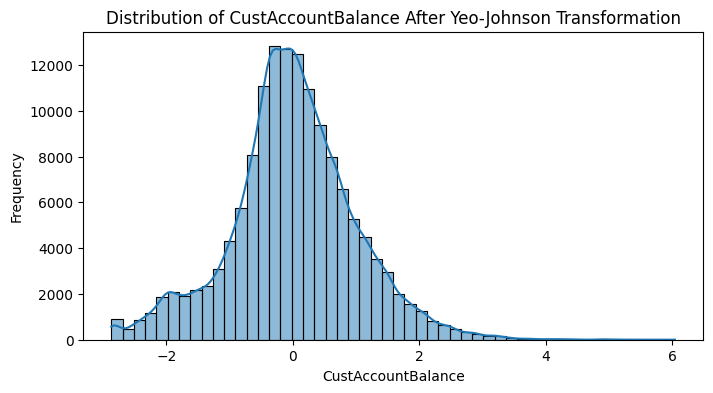

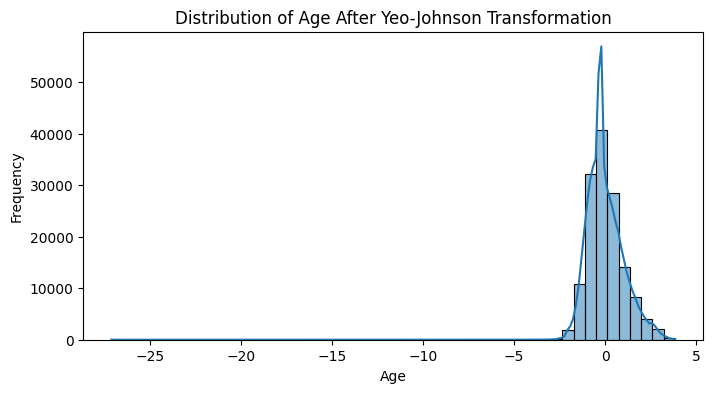

In [ ]:
for col in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_transformed_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col} After Yeo-Johnson Transformation")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
X_transformed_df.describe().loc[["mean", "std"]]

,Recency,Frequency,Monetary,AvgTransactionAmount,CustAccountBalance,Age
mean,-9.119201e-17,-1.394366e-18,2.907615e-16,1.041221e-15,-2.323012e-16,-6.858474e-15
std,1.000003e+00,3.026073e-14,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00


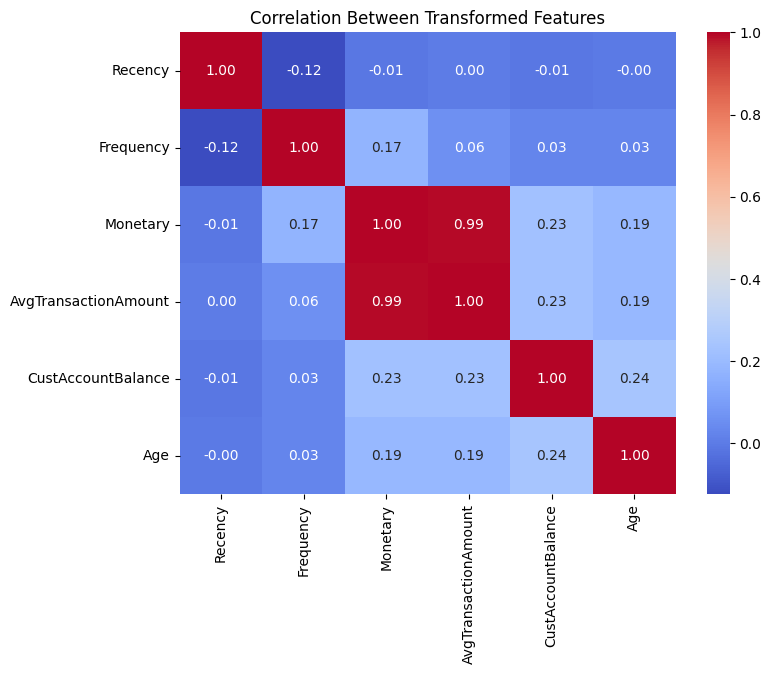

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    X_transformed_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Transformed Features")
plt.show()

## What the Correlation Tells Us

The main issue is very clear:

- `Monetary` and `AvgTransactionAmount` have a correlation of **0.99**.

That's extremely high. Since:

$$
\text{AvgTransactionAmount} = \dfrac{\text{Monetary}}{\text{Frequency}}
$$

these two features are carrying almost the same information in our dataset.

- If we put both into K-Means, we're effectively giving transaction value **extra weight**.

**Recommendation:** We will drop `AvgTransactionAmount`.

#**6.MODELLING**

In [ ]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "CustAccountBalance",
    "Age"
]

pt = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)

X_transformed = pt.fit_transform(rfm[features])

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=features,
    index=rfm.index
)

In [ ]:
from tqdm.auto import tqdm
import numpy as np

np.random.seed(42)

sample_size = 20000

sample_idx = np.random.choice(
    len(X_transformed),
    sample_size,
    replace=False
)

X_sample = X_transformed[sample_idx]

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 11)

inertia = []
silhouette_scores = []

for k in tqdm(k_values, desc="Testing K values"):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_sample, labels)
    )

Testing K values:   0%|          | 0/9 [00:00<?, ?it/s]

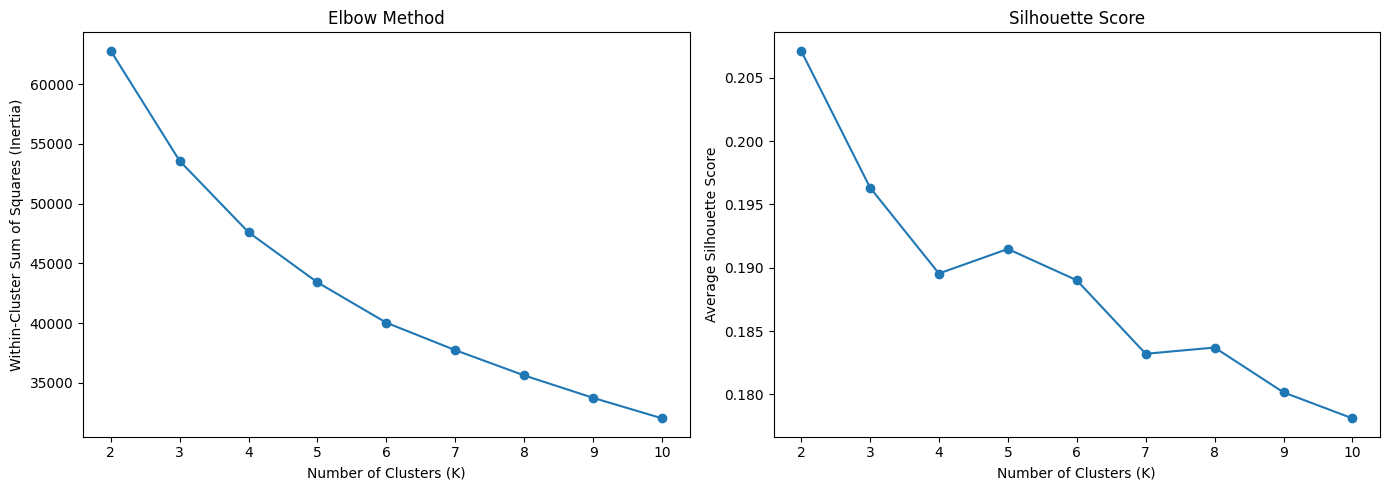

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_values, inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares (Inertia)")
axes[0].set_xticks(k_values)

# Silhouette
axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Average Silhouette Score")
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

###**PCA for Dimensionality Reduction**

Since the clustering is performed using multiple customer-level features, it is difficult to visualize the resulting clusters directly in the original feature space. **Principal Component Analysis (PCA)** is therefore used to reduce the transformed feature space to two dimensions.

PCA creates new orthogonal components that capture the maximum possible variance from the original features. The first two principal components are then used to visualize the relative position and separation of customers in a two-dimensional space.

It is important to note that **PCA is used here only for visualization and not for performing the K-Means clustering itself**. K-Means is fitted on the PowerTransformed feature space, while PCA provides a two-dimensional representation of that space.


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca_sample = pca.fit_transform(X_sample)

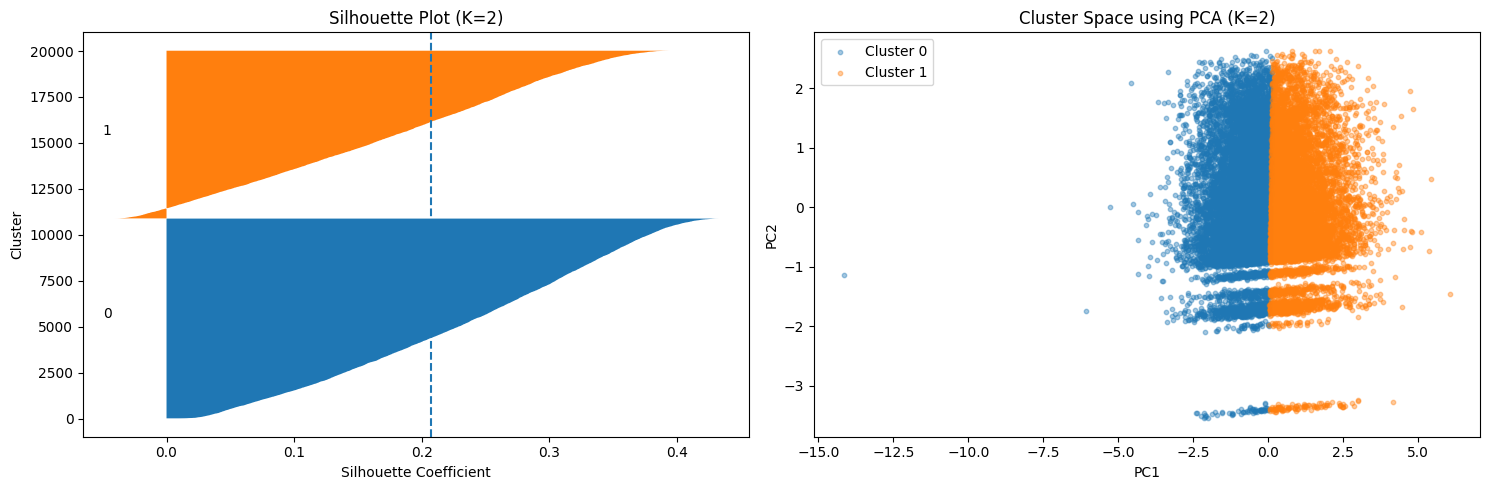

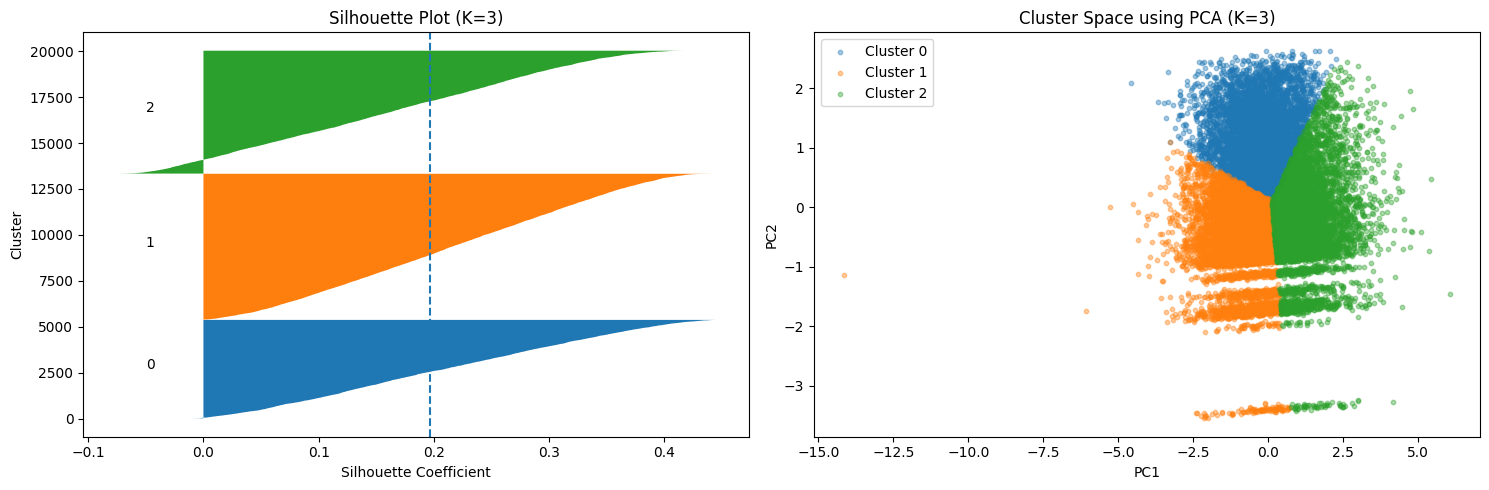

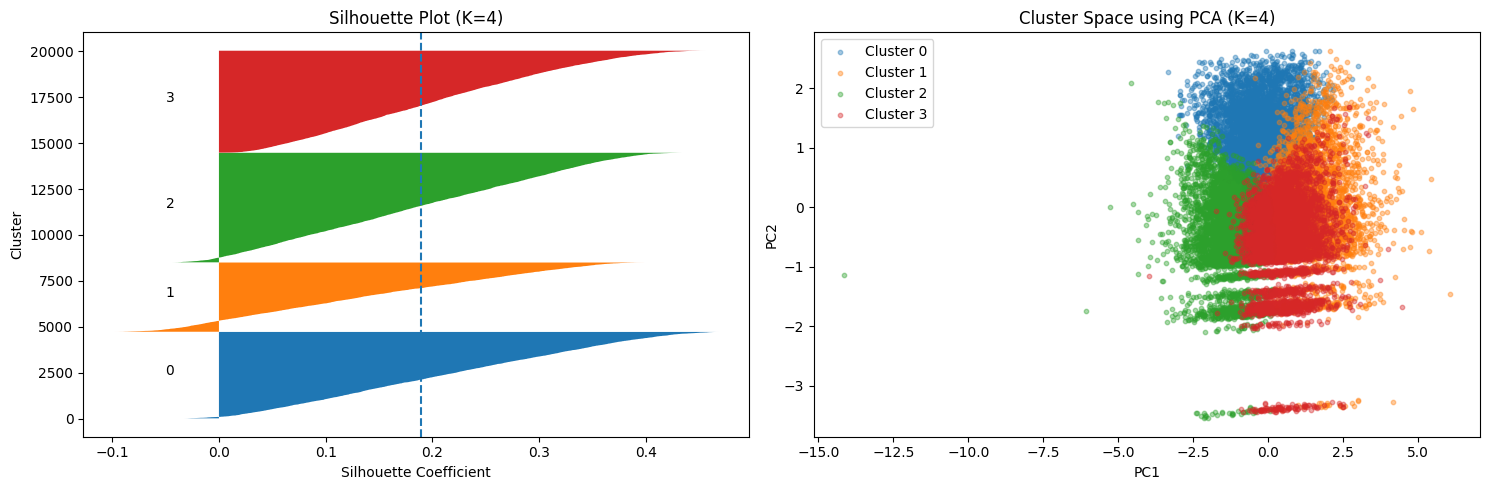

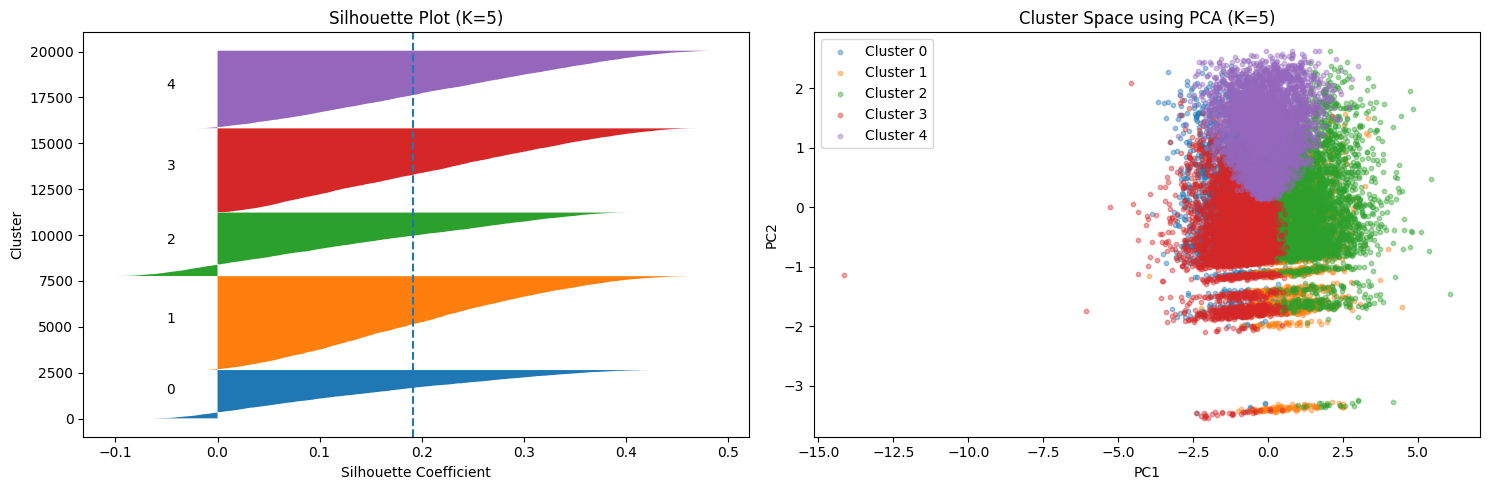

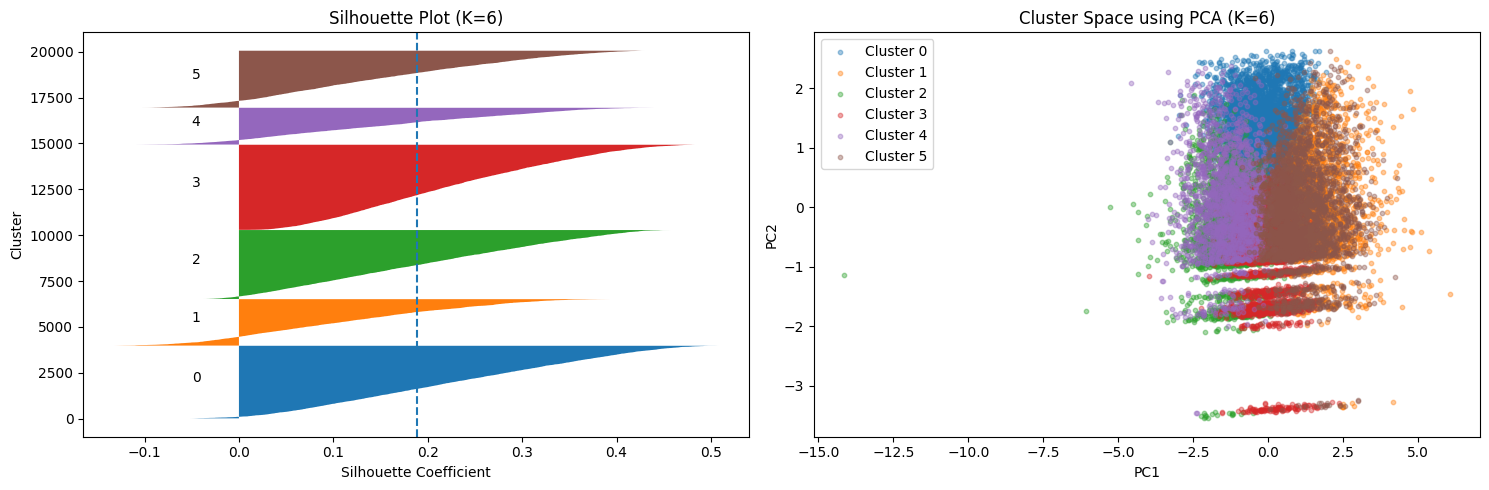

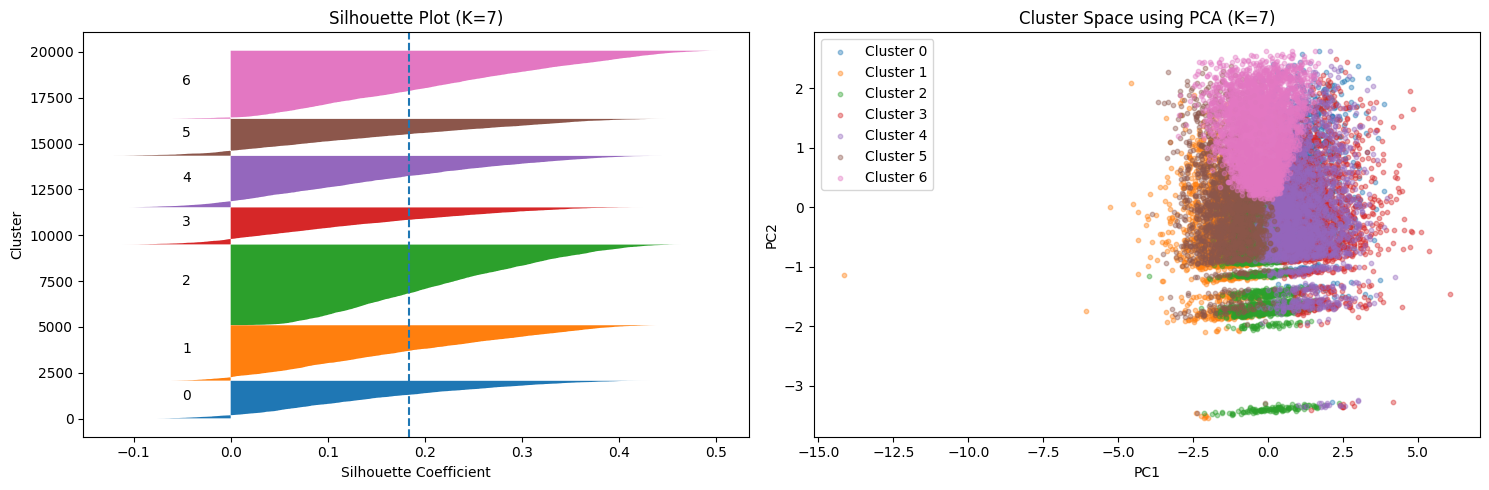

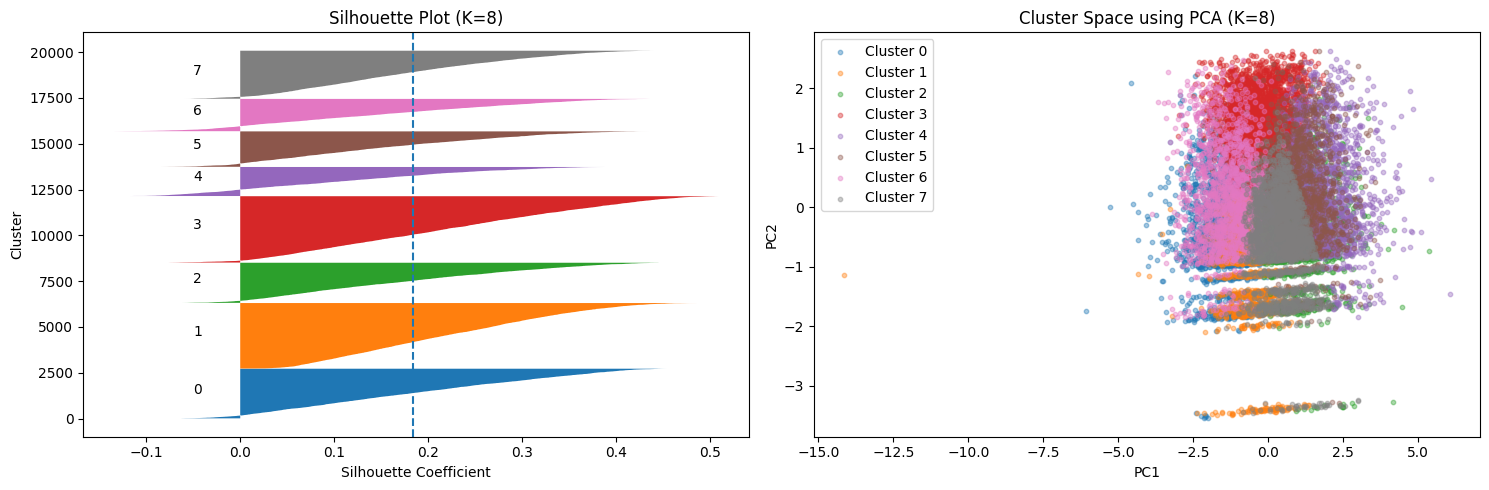

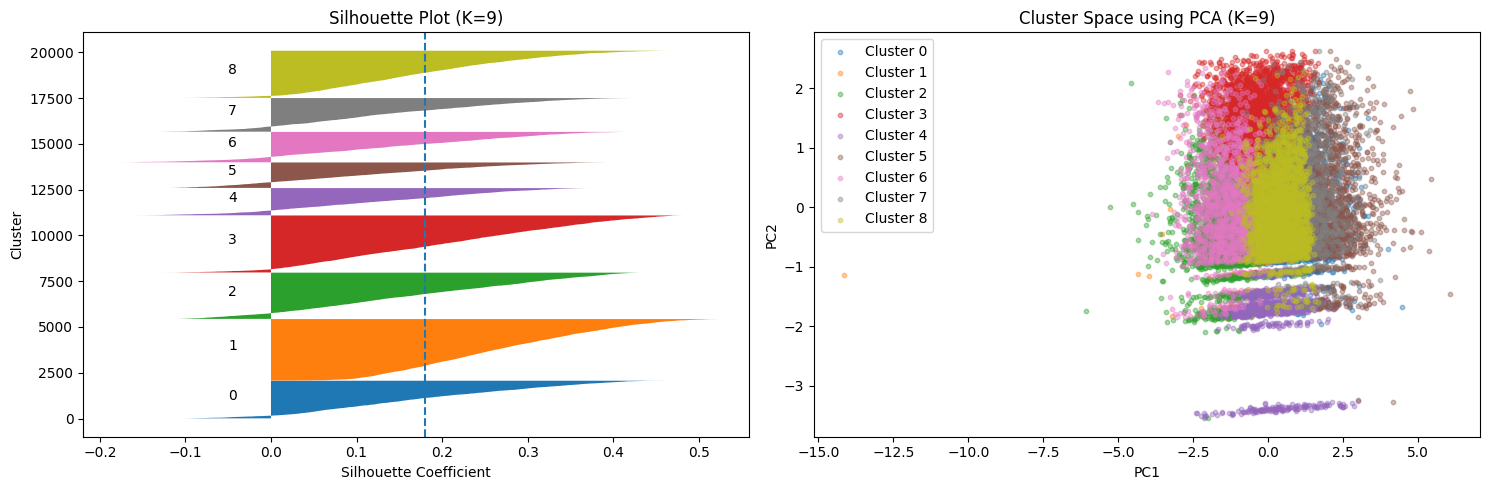

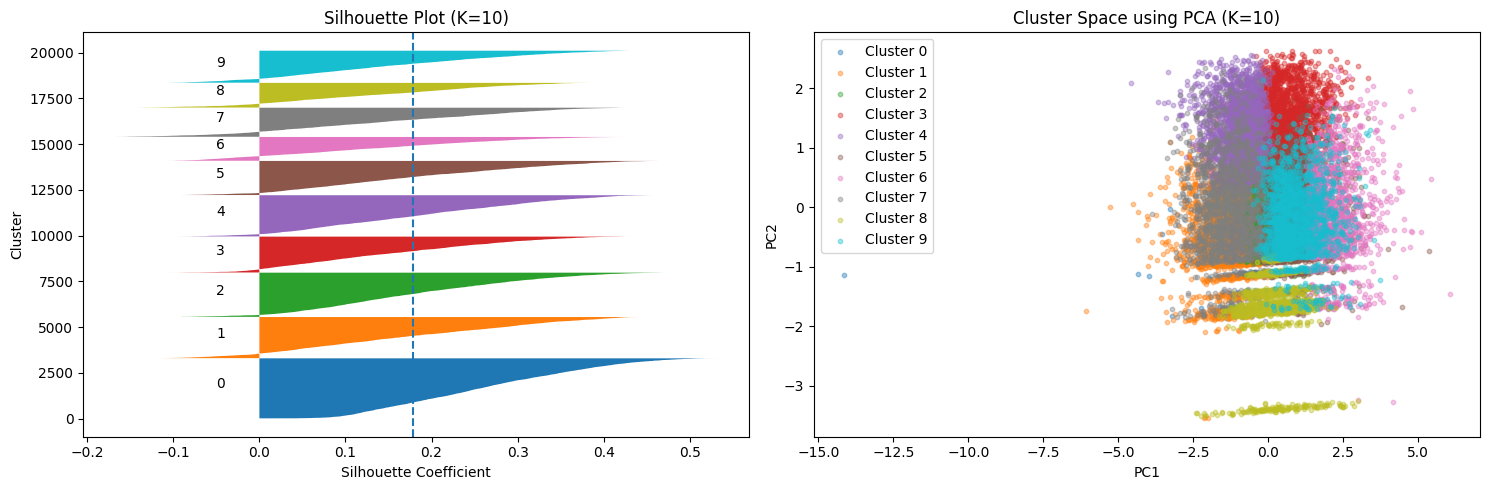

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    silhouette_avg = silhouette_score(
        X_sample,
        labels
    )

    sample_silhouette_values = silhouette_samples(
        X_sample,
        labels
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(15, 5)
    )

    # --------------------------------
    # 1. Silhouette Plot
    # --------------------------------

    y_lower = 10

    for cluster in range(k):

        cluster_values = sample_silhouette_values[
            labels == cluster
        ]

        cluster_values.sort()

        size_cluster = cluster_values.shape[0]

        y_upper = y_lower + size_cluster

        axes[0].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_values
        )

        axes[0].text(
            -0.05,
            y_lower + 0.5 * size_cluster,
            str(cluster)
        )

        y_lower = y_upper + 10

    axes[0].axvline(
        x=silhouette_avg,
        linestyle="--"
    )

    axes[0].set_title(
        f"Silhouette Plot (K={k})"
    )

    axes[0].set_xlabel(
        "Silhouette Coefficient"
    )

    axes[0].set_ylabel(
        "Cluster"
    )

    # --------------------------------
    # 2. Cluster Space
    # --------------------------------

    for cluster in range(k):

        axes[1].scatter(
            X_pca_sample[labels == cluster, 0],
            X_pca_sample[labels == cluster, 1],
            label=f"Cluster {cluster}",
            alpha=0.4,
            s=10
        )

    axes[1].set_title(
        f"Cluster Space using PCA (K={k})"
    )

    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")

    axes[1].legend()

    plt.tight_layout()
    plt.show()

#**7.CLUSTER ANALYSIS**

###**7.1 Selection of Candidate Number of Clusters**

- The **Elbow method** shows a significant reduction in within-cluster variation at lower values of K, followed by diminishing improvements as K increases.
- The **Silhouette Score** is highest for K=2 (≈0.207) and remains reasonably close for K=3 (≈0.196).
- As K increases beyond 3, the silhouette score generally decreases and the **PCA cluster-space plots** show increasing overlap between clusters.

Therefore, **K=2** and **K=3** are selected as candidate solutions for further investigation.

- K=2 provides a simpler segmentation, while K=3 may provide a more useful business segmentation such as low-value, regular, and high-value customers.

The final choice will be based not only on clustering metrics but also on **cluster size, RFM characteristics, transaction behaviour, account balance**, and **business interpretability**.

In [ ]:
from sklearn.cluster import KMeans

cluster_results = {}

for k in [2, 3]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_transformed)

    cluster_results[k] = {
        "model": kmeans,
        "labels": labels
    }

In [ ]:
profile_columns = [
    "Age",
    "Recency",
    "Frequency",
    "Monetary",
    "AvgTransactionAmount",
    "CustAccountBalance"
]

for k in [2, 3]:

    temp = rfm.copy()
    temp["Cluster"] = cluster_results[k]["labels"]

    print(f"\n{'='*50}")
    print(f"K = {k}")
    print(f"{'='*50}")

    profile = temp.groupby("Cluster")[profile_columns].agg(
        ["mean", "median"]
    ).round(2)

    display(profile)


K = 2


Age        Recency        Frequency        Monetary          \
          mean median    mean median      mean median     mean  median   
Cluster                                                                  
0        42.28   40.0   48.17   47.0      2.18    2.0  5783.96  2681.0   
1        32.96   32.0   48.95   48.0      2.11    2.0  1329.83   816.0   

        AvgTransactionAmount         CustAccountBalance            
                        mean  median               mean    median  
Cluster                                                            
0                    2688.12  1243.0          315652.51  75075.98  
1                     628.15   390.5           23724.66   9906.60


K = 3


Age        Recency        Frequency        Monetary           \
          mean median    mean median      mean median     mean   median   
Cluster                                                                   
0        35.35   34.0   64.35   64.0      2.08    2.0  2300.26  1240.00   
1        32.96   32.0   41.40   42.0      2.14    2.0  1373.60   828.60   
2        43.67   41.0   44.71   44.0      2.21    2.0  6537.71  2943.13   

        AvgTransactionAmount         CustAccountBalance            
                        mean  median               mean    median  
Cluster                                                            
0                    1108.74   599.0           61905.65  19158.78  
1                     639.26   391.5           24957.02  10014.96  
2                    3022.56  1345.0          386909.82  92300.63

In [ ]:
for k in [2, 3]:

    labels = cluster_results[k]["labels"]

    size = pd.Series(labels).value_counts().sort_index()

    percentage = (
        size / len(labels) * 100
    ).round(2)

    result = pd.DataFrame({
        "Customers": size,
        "Percentage": percentage
    })

    print(f"\nK = {k}")
    display(result)


K = 2


,Customers,Percentage
0,65324,45.66
1,77732,54.34



K = 3


,Customers,Percentage
0,37892,26.49
1,56833,39.73
2,48331,33.78


In [ ]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

In [ ]:
rfm[
    ["Recency", "Frequency", "Monetary",
     "R_Score", "F_Score", "M_Score", "RFM_Score"]
].head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,26,2,5106.0,5,1,5,11
1,76,2,1455.0,1,1,3,5
2,79,2,1864.0,1,1,3,5
3,56,2,750.0,2,1,2,5
4,42,3,16917.0,4,5,5,14


In [ ]:
for k in [2, 3]:

    temp = rfm.copy()
    temp["Cluster"] = cluster_results[k]["labels"]

    profile = (
        temp.groupby("Cluster")
        .agg(
            Customers=("CustomerID", "count"),
            Recency=("Recency", "mean"),
            Frequency=("Frequency", "mean"),
            Monetary=("Monetary", "mean"),
            RFM_Score=("RFM_Score", "mean"),
            AccountBalance=("CustAccountBalance", "mean"),
            AvgTransaction=("AvgTransactionAmount", "mean"),
            Age=("Age", "mean")
        )
        .round(2)
    )

    print(f"\n========== K = {k} ==========")
    display(profile)


========== K = 2 ==========


,Customers,Recency,Frequency,Monetary,RFM_Score,AccountBalance,AvgTransaction,Age
Cluster,,,,,,,,
0,65324,48.17,2.18,5783.96,9.94,315652.51,2688.12,42.28
1,77732,48.95,2.11,1329.83,8.21,23724.66,628.15,32.96



========== K = 3 ==========


,Customers,Recency,Frequency,Monetary,RFM_Score,AccountBalance,AvgTransaction,Age
Cluster,,,,,,,,
0,37892,64.35,2.08,2300.26,7.04,61905.65,1108.74,35.35
1,56833,41.40,2.14,1373.60,9.09,24957.02,639.26,32.96
2,48331,44.71,2.21,6537.71,10.43,386909.82,3022.56,43.67


###**7.2 RFM-Based Validation of K=3**

- The RFM scores were compared across the candidate clustering solutions.
- For K=2, the average RFM scores were approximately **8.21** and **9.94**, resulting in two relatively broad customer groups.
- For K=3, the average RFM scores were approximately **7**, **9**, and **10**, providing a clearer three-level differentiation in customer value.
- The RFM differences are consistent with the differences observed in **Monetary value**, **Average Transaction Amount**, and **Account Balance**.
- This indicates that K=3 provides a more interpretable segmentation of **low-value, regular, and high-value** customers.

**Therefore, K=3 is selected as the final segmentation solution.**

In [ ]:
# Creating final K=3 dataframe
df_clustered = rfm.copy()

df_clustered["Cluster"] = cluster_results[3]["labels"]
final_profile = (
    df_clustered
    .groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Recency=("Recency", "median"),
        Frequency=("Frequency", "median"),
        Monetary=("Monetary", "median"),
        AvgTransactionAmount=("AvgTransactionAmount", "median"),
        CustAccountBalance=("CustAccountBalance", "median"),
        Age=("Age", "median"),
        RFM_Score=("RFM_Score", "mean")
    )
)

# Customer percentage
final_profile["Percentage"] = (
    final_profile["Customers"]
    / len(df_clustered) * 100
).round(2)

final_profile = final_profile.round(2)

display(final_profile)

,Customers,Recency,Frequency,Monetary,AvgTransactionAmount,CustAccountBalance,Age,RFM_Score,Percentage
Cluster,,,,,,,,,
0,37892,64.0,2.0,1240.00,599.0,19158.78,34.0,7.04,26.49
1,56833,42.0,2.0,828.60,391.5,10014.96,32.0,9.09,39.73
2,48331,44.0,2.0,2943.13,1345.0,92300.63,41.0,10.43,33.78


###**7.3 Final Customer Segment Profiling**

After selecting K=3, each customer is assigned to one of three segments based on their behavioural characteristics:

* **Low-Value Customers:** Customers exhibiting relatively lower monetary contribution, transaction frequency and/or account balance.
* **Regular Customers:** Customers with moderate transaction activity and financial value, representing the core customer base.
* **High-Value Customers:** Customers with relatively higher monetary contribution, transaction frequency and account balance and therefore greater potential value to the bank.

The segments are profiled using Recency, Frequency, Monetary value, Account Balance, Average Transaction Amount, Age and RFM Score to understand the behavioural characteristics of each group.


In [ ]:
segment_names = {
    0: "Regular Customers",
    1: "Low-Value Customers",
    2: "High-Value Customers"
}

df_clustered["CustomerSegment"] = (
    df_clustered["Cluster"].map(segment_names)
)

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

np.random.seed(42)

sample_size = 10000

sample_idx = np.random.choice(
    len(X_transformed),
    sample_size,
    replace=False
)

X_tsne = X_transformed[sample_idx]

labels_tsne = df_clustered["Cluster"].values[sample_idx]

###**7.4 t-SNE Visualization**

While PCA provides a linear dimensionality reduction based on maximum variance, **t-SNE is used as a nonlinear visualization technique** to examine whether customers belonging to different segments form locally distinct groups.

The t-SNE representation is generated from the same PowerTransformed feature space used for clustering. A sample of customers is used because t-SNE is computationally expensive for very large datasets.

The visualization provides an additional qualitative check of the segmentation by showing the local neighbourhood structure of customers in two dimensions. However, t-SNE is used only for visualization and does not determine the cluster assignments.


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne_2d = tsne.fit_transform(X_tsne)

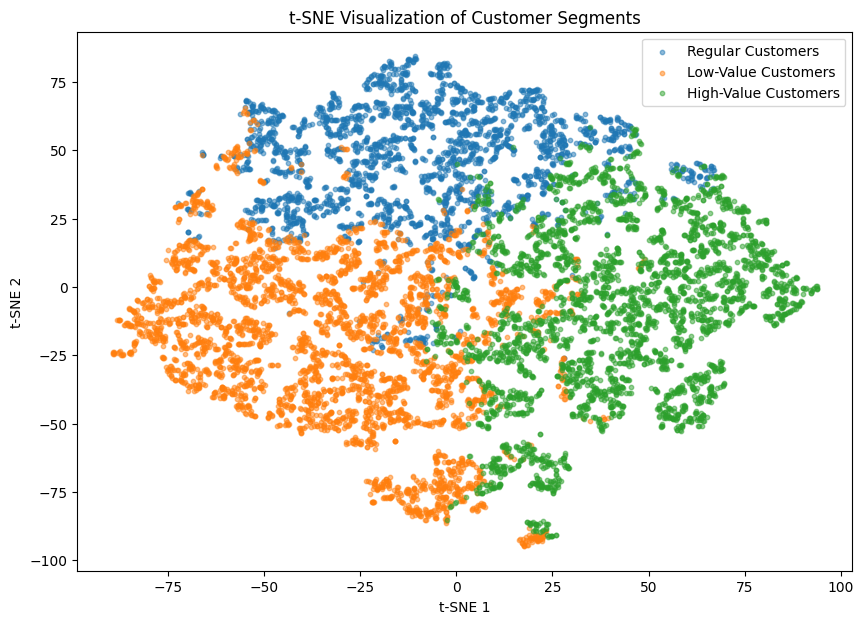

In [ ]:
plt.figure(figsize=(10, 7))

for cluster in sorted(np.unique(labels_tsne)):

    mask = labels_tsne == cluster

    plt.scatter(
        X_tsne_2d[mask, 0],
        X_tsne_2d[mask, 1],
        label=segment_names[cluster],
        alpha=0.5,
        s=10
    )

plt.title("t-SNE Visualization of Customer Segments")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.show()

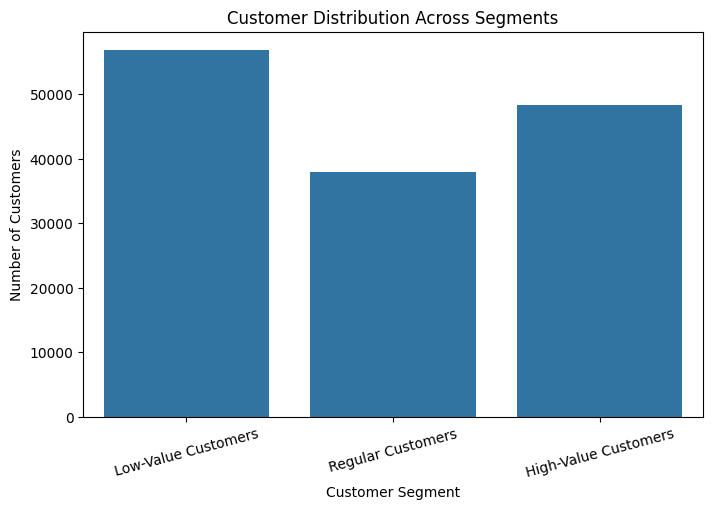

In [83]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clustered,
    x="CustomerSegment",
    order=["Low-Value Customers", "Regular Customers", "High-Value Customers"]
)

plt.title("Customer Distribution Across Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [84]:
segment_rfm = (
    df_clustered
    .groupby("CustomerSegment")[["Recency", "Frequency", "Monetary", "RFM_Score"]]
    .mean()
)

display(segment_rfm)

,Recency,Frequency,Monetary,RFM_Score
CustomerSegment,,,,
High-Value Customers,44.711572,2.206141,6537.709704,10.433945
Low-Value Customers,41.398026,2.135010,1373.598111,9.086499
Regular Customers,64.346828,2.076692,2300.263159,7.041222


In [ ]:
df_clustered.head()

,CustomerID,Recency,Frequency,Monetary,AvgTransactionAmount,CustGender,CustLocation,CustAccountBalance,Age,R_Score,F_Score,M_Score,RFM_Score,Cluster,CustomerSegment
0,C1010011,26,2,5106.0,2553.0,F,NOIDA,32500.73,29,5,1,5,11,1,Low-Value Customers
1,C1010014,76,2,1455.0,727.5,F,MUMBAI,38377.14,29,1,1,3,5,0,Regular Customers
2,C1010031,79,2,1864.0,932.0,M,TRICHY,8646.21,33,1,1,3,5,0,Regular Customers
3,C1010035,56,2,750.0,375.0,M,NAVI MUMBAI,378013.09,41,2,1,2,5,2,High-Value Customers
4,C1010041,42,3,16917.0,5639.0,F,DELHI,34119.48,28,4,5,5,14,2,High-Value Customers


# **8. BUSINESS RECOMMENDATIONS**

The customer segmentation provides three distinct customer groups: **Low-Value, Regular and High-Value Customers**. Instead of applying the same strategy to all customers, the bank can use segment-specific approaches based on their transaction behaviour, recency, frequency, monetary contribution and account balance.

### 1. Low-Value Customers

These customers show relatively lower engagement and financial contribution.

**Recommended strategies:**

* Introduce targeted offers to increase transaction frequency.
* Encourage digital banking and regular account usage.
* Provide personalized campaigns based on transaction behaviour.
* Use low-cost engagement strategies rather than expensive retention campaigns.
* Identify customers with high recency values and target them with reactivation campaigns.

**Objective:** Increase engagement and gradually move customers towards the regular segment.

### 2. Regular Customers

Regular customers represent the core customer base and provide consistent transaction activity.

**Recommended strategies:**

* Encourage higher transaction frequency through personalized offers.
* Introduce cross-selling opportunities such as additional banking products and services.
* Provide loyalty-based benefits to encourage continued engagement.
* Identify customers showing increasing monetary value and target them for high-value conversion.

**Objective:** Improve customer retention and increase customer lifetime value.

### 3. High-Value Customers

High-value customers contribute significantly through their transaction activity and financial value.

**Recommended strategies:**

* Provide personalized relationship management and premium services.
* Offer customized financial products based on their behaviour.
* Prioritize retention strategies because losing high-value customers can have a greater financial impact.
* Provide exclusive offers and loyalty benefits.
* Monitor changes in Recency and Frequency to identify early signs of reduced engagement.

**Objective:** Retain high-value customers and maximize their long-term value.

### Overall Business Strategy

The segmentation can therefore be used as a **customer prioritization framework**, where marketing efforts, retention strategies and product recommendations are tailored according to customer value rather than treating all customers equally.


# **9. DISCUSSION**

The analysis demonstrates that customer transaction behaviour can be represented effectively using customer-level RFM features along with account balance and age.

The clustering evaluation considered both quantitative metrics and business interpretability. Although K=2 produced a slightly higher Silhouette Score than K=3, the three-cluster solution provided a more meaningful segmentation of the customer base into **Low-Value, Regular and High-Value customers**. The RFM profiles and financial characteristics of the resulting clusters supported this interpretation.

The use of Power Transformation was important because several financial variables exhibited strong right-skewness. Transforming these variables reduced the influence of extreme values while retaining genuine high-value customers.

PCA and t-SNE were used as dimensionality-reduction techniques for visualization rather than as inputs to the clustering algorithm. PCA provided a linear two-dimensional representation of the feature space, while t-SNE provided a nonlinear representation that helped examine the local structure of the identified segments.

### Strengths

* Customer-level RFM features provide an interpretable representation of transaction behaviour.
* Power Transformation makes highly skewed financial variables more suitable for distance-based clustering.
* Multiple clustering evaluation methods were considered rather than relying on a single metric.
* The final clusters were validated using both clustering metrics and business-oriented customer profiles.
* The resulting segments can be directly connected to actionable business strategies.

### Limitations

* The analysis is based on historical transaction behaviour and does not directly predict future customer behaviour.
* K-Means assumes relatively well-defined cluster structures and relies on distance-based similarity.
* The selected number of clusters involves a degree of business judgement in addition to statistical evaluation.
* t-SNE is useful for visualization but should not be interpreted as proof of cluster quality.
* RFM features capture transaction behaviour but may not represent all factors influencing customer value, such as products owned, income, customer interactions or service usage.

Overall, the segmentation provides a useful framework for understanding customer heterogeneity and developing targeted strategies, while further behavioural and temporal information could improve the segmentation in future work.


# **10. CONCLUSION**

This project developed a customer segmentation framework using transaction data and unsupervised machine learning.

The analysis began with data preparation and exploratory analysis, followed by the creation of customer-level behavioural features using **Recency, Frequency and Monetary value**. Additional characteristics such as account balance and age were incorporated to provide a broader representation of customer behaviour.

Because the numerical features exhibited substantial skewness, **Yeo-Johnson Power Transformation** was applied before K-Means clustering. Different values of K were evaluated using the Elbow method, Silhouette Score, cluster profiles and visual analysis. Although K=2 achieved a slightly higher Silhouette Score, **K=3 was selected because it provided a more meaningful and actionable business segmentation**.

The final segmentation identified three customer groups: **Low-Value, Regular and High-Value Customers**. These segments provide a basis for differentiated marketing, engagement, cross-selling and retention strategies.

PCA and t-SNE were additionally used to visualize the customer feature space and examine the structure of the resulting segments.

Overall, the analysis demonstrates how customer transaction data can be transformed into actionable customer segments using RFM analysis and K-Means clustering. The resulting framework can support more targeted customer management and can be extended in the future using additional behavioural data and periodic re-segmentation.
